<a href="https://colab.research.google.com/github/loui137/Diabetes/blob/main/louis_Agbanye.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TS Academy Data Science Capstone Project

## Submission Summary

| Item | Details |
|---|---|
| **Group number** | 14 |
| **Full name** | Agbanye Chikwado Louis |
| **Dataset** | Telco Customer Churn |
| **Depth track** | Classification Depth |
| **Team members** | Salwa Olonade, Oluwarotimi Esther Yewande,Fawoye Michael Omotayo, Olawuni progress oluwafunmike, Gbijah Benjamin Anjolajesu, Ridwan Oluwadamilare Odewole, Isa Rasheed Tayo |
| **Final model** | Logistic Regression, Threshold 0.30 |
| **Stratified dummy F1 / ROC AUC** | 0.2679 / 0.5020 |
| **Final model F1 / ROC AUC** | 0.6250 / 0.8503 |
| **Leakage columns dropped** | CustomerID excluded from modelling; no target-leakage column identified |
| **Full run time on Colab** | Approximately 235 seconds (3 minutes 55 seconds) |

## Group 14 — Telco Customer Churn

**Intending Problem:** Customer Retention Analytics Problem

**Big Question:** The analysis aims to answer the below business question:

How can a telecommunication company identify customer segments with different churn patterns/characteristics and develop a relaible predictive model to identify customers at risk of churn?

**Project Objective:** To identify natural customer segments and develop a machine learning model
for predicting customer churn.

**Dataset:** Telco Customer Churn

**Target Variable:** Churn

## Part 1: Data Foundation

### Import the Required Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np
import kagglehub
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# clustering, preprocessing and classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Setup Classifiers
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Preventing unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

# Pandas DataFrame Display Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# SQL
import sqlite3

print('Libraries imported successfully.')

Libraries imported successfully.


### Data Reconnaisance

#### Loading the Dataset

In [ ]:
# Install KaggleHub if required
!pip -q install kagglehub

In [ ]:
# Download the dataset directly from Kaggle
dataset_path = kagglehub.dataset_download(
    'blastchar/telco-customer-churn'
)

print('Dataset downloaded to:', dataset_path)
print('Files:', os.listdir(dataset_path))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset downloaded to: /kaggle/input/telco-customer-churn
Files: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
# Identify/read the CSV
csv_files = [
    file for file in os.listdir(dataset_path)
    if file.lower().endswith('.csv')
]

print('CSV files found:', csv_files)

CSV files found: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
csv_path = os.path.join(dataset_path, csv_files[0])

df_churn = pd.read_csv(csv_path)

print('Dataset Loaded Successfully')
print(f'Rows: {df_churn.shape[0]:,}')
print(f'Columns: {df_churn.shape[1]:,}')

Dataset Loaded Successfully
Rows: 7,043
Columns: 21


#### Dataset At a Glance

In [ ]:
display(df_churn.head())
display(df_churn.tail())
df_churn.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


#### Understanding the Data Structure

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Discovery:** TotalCharges appears as an object/string, rather than a numerical variable.

#### Data Dictionary for Systemic Structural Overview

In [ ]:
data_dictionary = pd.DataFrame({
    'Column': df_churn.columns,
    'Data_Type': df_churn.dtypes.astype(str).values,
    'Unique_Values': df_churn.nunique().values,
    'Missing_Values': df_churn.isnull().sum().values,
    'Missing_Pct': (df_churn.isnull().mean() * 100).round(2).values
})

data_dictionary

,Column,Data_Type,Unique_Values,Missing_Values,Missing_Pct
0,customerID,object,7043,0,0.0
1,gender,object,2,0,0.0
2,SeniorCitizen,int64,2,0,0.0
3,Partner,object,2,0,0.0
4,Dependents,object,2,0,0.0
5,tenure,int64,73,0,0.0
6,PhoneService,object,2,0,0.0
7,MultipleLines,object,3,0,0.0
8,InternetService,object,3,0,0.0
9,OnlineSecurity,object,3,0,0.0


#### Investigate Missing Values

The **df_churn.isnull().sum()** shows no missing values. However, there is need for investigation because **TotalCharges** is an object column, which could mean missing information may be represented as text rather than NaN.

In [ ]:
(df_churn == ' ').sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Inspect TotalCharges 11 Blank Values
df_churn[df_churn['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
df_churn.loc[df_churn['TotalCharges'] == ' ', ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


The important findings here is that the 11 blank TotalCharges records all have 0 tenure which could simply means that these customers have just joined and have no accumulated tenure.

#### Confirm TotalCharges Numeric Problem

In [ ]:
total_charges_numeric = pd.to_numeric(
    df_churn['TotalCharges'],
    errors = 'coerce'
)

print(f'Missing Values After Numeric Conversion: {total_charges_numeric.isnull().sum()}.This confirms that those blanks are genuinely non-numeric values.')


Missing Values After Numeric Conversion: 11.This confirms that those blanks are genuinely non-numeric values.


#### Check For Duplicate Records

In [ ]:
print('Duplicate Rows:', df_churn.duplicated().sum())
print('Duplicated Customer IDs:', df_churn['customerID'].duplicated().sum())
print('The Dataset has no duplicate record')

Duplicate Rows: 0
Duplicated Customer IDs: 0
The Dataset has no duplicate record


#### Understanding Categorical Variables
Basically to identify the values each categorical variable actually contain.

In [ ]:
categorical_columns = df_churn.select_dtypes(include = 'object').columns
for column in categorical_columns:
    print(f'\n{'='*60}')
    print(df_churn[column].value_counts())


customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes     

**Special attention on:**

- No internet service of 1526
- No phone service of 682

They're legitimate categories representing customers who do not subscribe to those services.

#### Investigating our Target Variable

**Target**: Churn

In [ ]:
churn_summary = pd.DataFrame({
    'Count': df_churn['Churn'].value_counts(),
    'Pct': (
        df_churn['Churn']
        .value_counts(normalize = True)
        .mul(100)
        .round(2))
        })

churn_summary

,Count,Pct
Churn,,
No,5174,73.46
Yes,1869,26.54


##### Visualize the Target

Text(0, 0.5, 'Number of Customers')

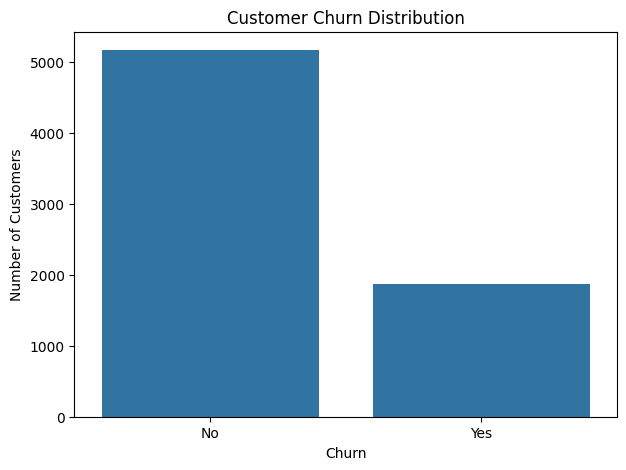

In [ ]:
plt.figure(figsize = (7, 5))

sns.countplot(data = df_churn, x = 'Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

Approximately **26.54% churned & 73.46% retained** is an indication that the classification problem is **imbalanced**.

#### Understanding Numerical Variables

In [ ]:
numerical_columns = df_churn.select_dtypes(include = np.number).columns

print(f'Numerical Columns: {list(numerical_columns)}')

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


Noticed **TotalCharges** isn't included because it is currently stored as text. This will rectify at the cleaning section.

##### Exploring the Main Numerical Variables

- tenure
- MonthlyCharges

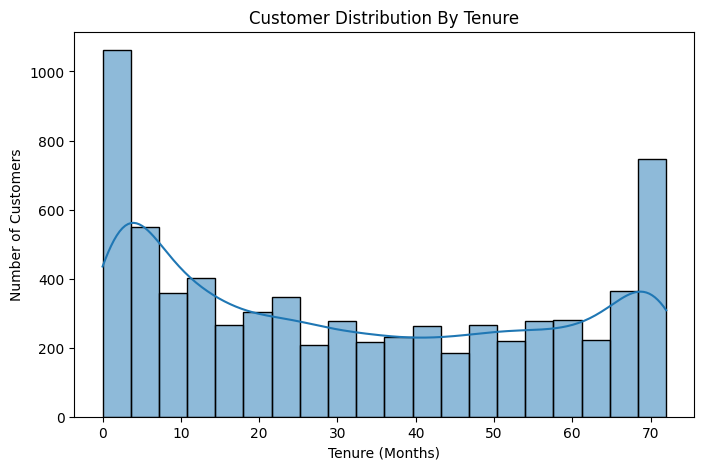

In [ ]:
# Tenure Visualization

plt.figure(figsize = (8, 5))

sns.histplot(data = df_churn, x = 'tenure', bins = 20, kde = True)

plt.title('Customer Distribution By Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

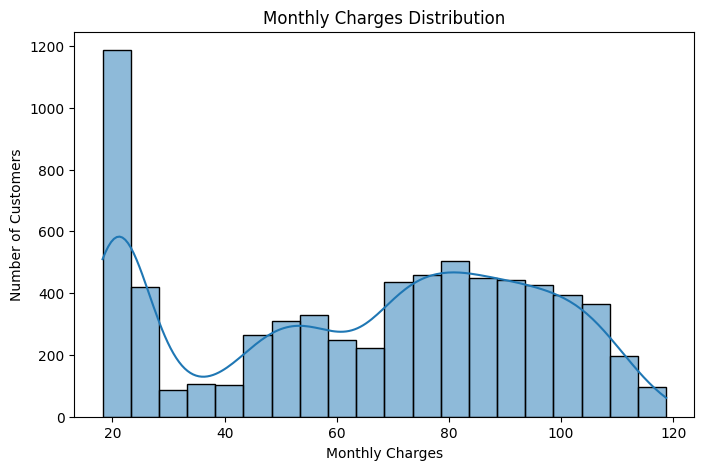

In [ ]:
# MonthlyCharges Visualization

plt.figure(figsize = (8, 5))

sns.histplot(data = df_churn, x = 'MonthlyCharges', bins = 20, kde = True)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

#### Business-Level Investigation
Investigate what appears to be associated with churn

In [ ]:
contract_churn = pd.crosstab(
    df_churn['Contract'],
    df_churn['Churn'],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


##### Systematic Churn Analysis
This Systematic Churn Analysis gives us a systematic reconnaissance of potential churn patterns

In [ ]:
for column in categorical_columns:

    if column != 'Churn':
        churn_rate = pd.crosstab(
            df_churn[column],
            df_churn['Churn'],
            normalize = 'index'
        )* 100

        if 'Yes' in churn_rate.columns:
            print(f'\n{'='*60}')
            print(f'Churn Rate by {column}')
            print(
                churn_rate['Yes']
                .sort_values(ascending = False)
                .round(2)
            )


Churn Rate by customerID
customerID
0013-EXCHZ    100.0
0004-TLHLJ    100.0
9985-MWVIX    100.0
9986-BONCE    100.0
9992-RRAMN    100.0
              ...  
9950-MTGYX      0.0
9953-ZMKSM      0.0
9955-QOPOY      0.0
9957-YODKZ      0.0
9958-MEKUC      0.0
Name: Yes, Length: 7043, dtype: float64

Churn Rate by gender
gender
Female    26.92
Male      26.16
Name: Yes, dtype: float64

Churn Rate by Partner
Partner
No     32.96
Yes    19.66
Name: Yes, dtype: float64

Churn Rate by Dependents
Dependents
No     31.28
Yes    15.45
Name: Yes, dtype: float64

Churn Rate by PhoneService
PhoneService
Yes    26.71
No     24.93
Name: Yes, dtype: float64

Churn Rate by MultipleLines
MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Yes, dtype: float64

Churn Rate by InternetService
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Yes, dtype: float64

Churn Rate by OnlineSecurity
OnlineSecurity
No                     

#### Summary of Our Reconnaissance
From the dataset, our reconnaissance has established the following:

**Dataset structure**

- 7,043 customers
- 21 columns
- Target = Churn

**Data quality**

- No duplicate rows
- No duplicate customer IDs
- 11 hidden blank values in TotalCharges
- All 11 occur at tenure = 0

**Important modelling consideration**
- customerID is an identifier and should not be used as a predictive feature.
- "No internet service" and "No phone service" are legitimate categories.
- TotalCharges requires numeric conversion.

**Target**

- 26.54% churn
- 73.46% retained
- This creates a class-imbalance consideration for later modelling.

**Early patterns**

The exploratory analysis indicates that churn rates vary across customer characteristics such as:

- contract type
- internet service
- payment method
- tenure etc.


### Part 1. Data Foundation - SQL Analysis

**Create a SQLite Database**

To complement the Python-based exploratory analysis, the dataset is loaded into a SQLite database. SQL is used to demonstrate how customer-level information can be queried and aggregated using a relational database approach.

The SQL analysis focuses on business questions that are relevant to customer churn, including differences in churn across contract types, internet-service categories, and customer spending.

In [ ]:
# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load the dataframe into SQLite
df_churn.to_sql('df_churn', conn, index = False, if_exists = 'replace')

print('Dataset successfully loaded into SQLite.')

Dataset successfully loaded into SQLite.


In [ ]:
# Verify the connection
tables = pd.read_sql_query(
    """
    Select Name
    From sqlite_master
    Where type = 'table';
    """,
    conn
)

tables

,name
0,df_churn


#### SQL Query 1 - Churn by Contract Type

This analysis is useful because contract structure represents an important dimension of the customer relationship. Comparing churn outcomes across contract types allows us to identify whether observed churn rates differ between month-to-month, one-year, and two-year customers.

In [ ]:
query_1 = """
SELECT
    Contract,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Churn_Rate_Percent
FROM df_churn
GROUP BY Contract
ORDER BY Churn_Rate_Percent DESC;
"""

sql_contract = pd.read_sql_query(query_1, conn)

sql_contract

,Contract,Total_Customers,Churned_Customers,Churn_Rate_Percent
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


Churn rate is important metric as it better than simply the number of churned customers.

**Observation:** Customers with short term contract are more suceptible to churning than the long term customers.

#### Query 2: Churn by Internet Service

The second query investigates customer churn across internet-service categories. The purpose is to determine whether observed churn rates vary between customers using DSL, fiber optic, and customers without internet service. The analysis provides another perspective on the relationship between service characteristics and customer retention

In [ ]:
query_2 = """
SELECT
    InternetService,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Churn_Rate_Percent
FROM df_churn
GROUP BY InternetService
ORDER BY Churn_Rate_Percent DESC;
"""

sql_internet = pd.read_sql_query(query_2, conn)

sql_internet

,InternetService,Total_Customers,Churned_Customers,Churn_Rate_Percent
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


#### Query 3: Average Monthly Charges by Churn Status

The third query compares average monthly charges between customers who churned and customers who remained. This provides an initial view of whether customer spending levels differ between the two churn outcomes.

In [ ]:
query_3 = """
SELECT
    Churn,
    COUNT(*) AS Customer_Count,
    AVG(MonthlyCharges) AS Avg_Monthly_Charges
FROM df_churn
GROUP BY Churn;
"""

sql_spending = pd.read_sql_query(query_3, conn)

sql_spending

,Churn,Customer_Count,Avg_Monthly_Charges
0,No,5174,61.265124
1,Yes,1869,74.441332


#### Cleaning the Dataset

Addressing all our discoveries during reconnaissance.

##### Create a Working Copy

In [ ]:
df_churn_clean = df_churn.copy()

print(f'Original shape: {df_churn.shape}')
print(f'Working Dataset shape: {df_churn_clean.shape}')

Original shape: (7043, 21)
Working Dataset shape: (7043, 21)


Both has 7,043 rows and 21 columns and this gives us a uniform reference version

##### Convert TotalCharges

The TotalCharges column is stored as a text field even though it represents a monetary amount. During reconnaissance, 11 records were found containing blank strings rather than numerical values.

These records all have a tenure of zero months. Because total accumulated charges are logically expected to be zero for customers with zero tenure, the blank values will be **converted to numeric missing values and then set to zero.**

In [ ]:
# Convert TotalCharges to numeric
df_churn_clean['TotalCharges'] = pd.to_numeric(
    df_churn_clean['TotalCharges'],
    errors = 'coerce'
)

print('Missing TotalCharges after conversion:',
      df_churn_clean['TotalCharges'].isnull().sum()
     )

Missing TotalCharges after conversion: 11


##### Replace the Missing Values

In [ ]:
df_churn_clean['TotalCharges'] = df_churn_clean['TotalCharges'].fillna(0)

# Verify
print('Missing TotalCharges after Fillna:',
      df_churn_clean['TotalCharges'].isnull().sum()
     )

# Confirming Data Type
print(f'Data Type: {df_churn_clean['TotalCharges'].dtypes}')

Missing TotalCharges after Fillna: 0
Data Type: float64


We considered this important because TotalCharges can now participate correctly in descriptive statistics, correlation analysis, visualizations, feature engineering, machine-learning preprocessing.

##### Data Quality Re-check

In [ ]:
quality_check = pd.DataFrame({
    'Column': df_churn_clean.columns,
    'Data_Type': df_churn_clean.dtypes.astype(str).values,
    'Unique_Values': df_churn_clean.nunique().values,
    'Missing_Values': df_churn_clean.isnull().sum().values,
    'Missing_Pct': (df_churn_clean.isnull().mean() * 100).round(2).values
})

quality_check

,Column,Data_Type,Unique_Values,Missing_Values,Missing_Pct
0,customerID,object,7043,0,0.0
1,gender,object,2,0,0.0
2,SeniorCitizen,int64,2,0,0.0
3,Partner,object,2,0,0.0
4,Dependents,object,2,0,0.0
5,tenure,int64,73,0,0.0
6,PhoneService,object,2,0,0.0
7,MultipleLines,object,3,0,0.0
8,InternetService,object,3,0,0.0
9,OnlineSecurity,object,3,0,0.0


##### Re-validate Numerical Statistics

In [ ]:
df_churn_clean[[
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


##### TotalCharges Distribution

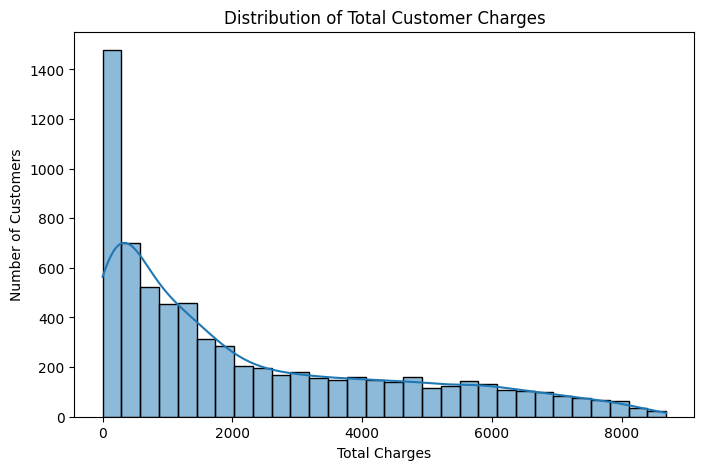

In [ ]:
plt.figure(figsize = (8, 5))

sns.histplot(
    data = df_churn_clean,
    x = 'TotalCharges',
    bins = 30,
    kde = True
)

plt.title('Distribution of Total Customer Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

##### Check for other Hidden Blanks

One of the discoveries during reconnaissance involved text-based blanks, therefore, there is need to explicitly check all object columns for blank.

In [ ]:
object_columns = df_churn_clean.select_dtypes(include = 'object').columns

for column in object_columns:
    blank_count = (df_churn_clean[column] == ' ').sum()

    if blank_count > 0:
        print(f'{column}: {blank_count} blank values')

**Nothing prints.** It means we've successfully eliminated hidden blank strings.

#### Leakage Review

Before modelling, each variable should be assessed for whether it provides legitimate predictive information or could introduce leakage.

**customerID** is a unique customer identifier. It does not describe customer behaviour or characteristics and therefore will not be used as a predictive feature.

The target variable, **Churn**, will also be excluded from feature construction and clustering inputs. In particular, customer clustering will be performed without using the churn outcome so that the relationship between independently discovered customer segments and churn can be evaluated

In [ ]:
print('Unique Customer ID:', df_churn_clean['customerID'].is_unique)
print('Target Value:', df_churn_clean['Churn'].unique())

Unique Customer ID: True
Target Value: ['No' 'Yes']


### Exploratory Data Analysis

**Our analysis explored the below questions:**

- What does the customer base look like?
- How does churn vary across customer characteristics?
- How does tenure relate to churn?
- How do charges relate to churn?
- Which services and contract characteristics show notable churn differences?

#### Customer Base Overview

Our exploratory analysis examines the composition of the customer base. Understanding customer characteristics provides context for interpreting subsequent churn patterns. The analysis considers demographic attributes, tenure, billing characteristics, contract structure, and subscribed services.

##### Customer Demographics
We examined gender, SeniorCitizen, Partner, and Dependent status.

In [ ]:
demographic_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]

for col in demographic_cols:
    print(f'\n{'='*60}')
    display(
        (df_churn_clean[col].value_counts(normalize = True) * 100)
    .round(2)
    )

,proportion
gender,
Male,50.48
Female,49.52


,proportion
SeniorCitizen,
0,83.79
1,16.21


,proportion
Partner,
No,51.7
Yes,48.3


,proportion
Dependents,
No,70.04
Yes,29.96


This tells us whether the dataset is reasonably distributed or dominated by particular customer groups.

##### Churn by Demographic Characteristics

We answered "Do churn rates differ across customer groups?"

In [ ]:
# Create a reusable function:
def calculate_churn_rate(data, column):
    result = (
        data.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
    )
    return result

for col in demographic_cols:
    print(f"\n{'='*60}")
    print(f"Churn Rate by {col}")
    display(calculate_churn_rate(df_churn_clean, col))


Churn Rate by gender


,Churn
gender,
Female,26.92
Male,26.16



Churn Rate by SeniorCitizen


,Churn
SeniorCitizen,
1,41.68
0,23.61



Churn Rate by Partner


,Churn
Partner,
No,32.96
Yes,19.66



Churn Rate by Dependents


,Churn
Dependents,
No,31.28
Yes,15.45


##### Visualizing Senior Citizen Churn

Because it has a particularly notable difference in the dataset.

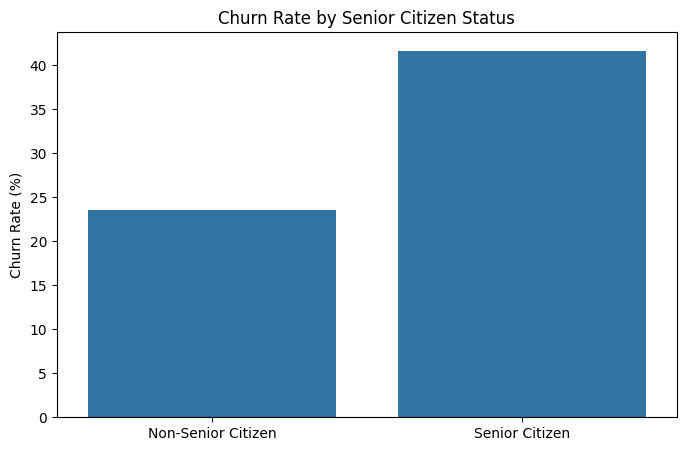

In [ ]:
senior_churn = (
    df_churn_clean.groupby('SeniorCitizen')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='ChurnRate')
)

senior_churn['SeniorCitizen'] = senior_churn['SeniorCitizen'].map({
    0: 'Non-Senior Citizen',
    1: 'Senior Citizen'
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data = senior_churn,
    x = 'SeniorCitizen',
    y = 'ChurnRate'
)

plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('')
plt.ylabel('Churn Rate (%)')

plt.show()

The observed churn rates are approximately:

- **Non-senior customers: 23.61%**
- **Senior customers: 41.68%**

The observed churn rate differs substantially between the two groups. However, this is just an observed association in this dataset. We could not conclude that senior-citizen status itself causes churn.

##### Tenure Analysis

Compare tenure between churn groups

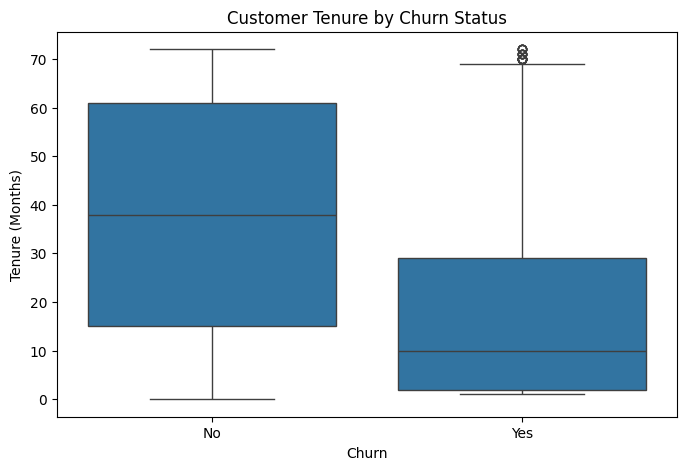

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data = df_churn_clean,
    x = 'Churn',
    y = 'tenure'
)

plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

This box plot reveals a strong inverse relationship between customer tenure and churn status, demonstrating that long-term customers are highly stable, whereas churn is heavily concentrated among newer accounts.

In [ ]:
# calculate the means:
df_churn_clean.groupby('Churn')['tenure'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


In [ ]:
# Create Tenure Bands
tenure_bins = [-1, 12, 24, 48, 60, 72]

tenure_labels = [
    '0-12 months',
    '13-24 months',
    '25-48 months',
    '49-60 months',
    '61-72 months'
]

df_churn_clean['TenureBand'] = pd.cut(
    df_churn_clean['tenure'],
    bins = tenure_bins,
    labels = tenure_labels
)

# Calculate Churn
tenure_churn = (
    df_churn_clean.groupby("TenureBand", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
).round(2)

tenure_churn

,TenureBand,ChurnRate
0,0-12 months,47.44
1,13-24 months,28.71
2,25-48 months,20.39
3,49-60 months,14.42
4,61-72 months,6.61


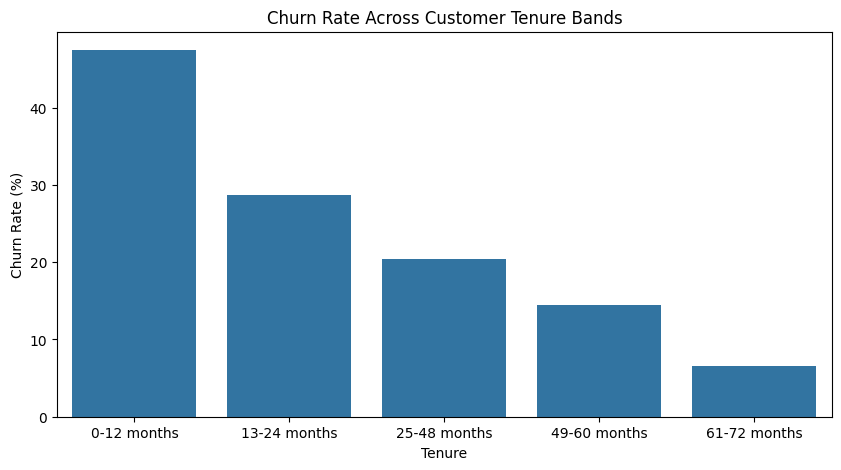

In [ ]:
# Visualize Churn by Tenure Band
plt.figure(figsize = (10, 5))

sns.barplot(
    data = tenure_churn,
    x = 'TenureBand',
    y = 'ChurnRate'
)

plt.title('Churn Rate Across Customer Tenure Bands')
plt.xlabel('Tenure')
plt.ylabel('Churn Rate (%)')


plt.show()

**Observation:** The data shows that customers in shorter-tenure bands have substantially higher observed churn rates than customers with longer tenure.

But again, this is "associated with" rather than "causes."

##### Contract Analysis

In [ ]:
# Computing Churn
contract_churn = (
    df_churn_clean.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name = 'ChurnRate')
    .sort_values('ChurnRate', ascending=False)
).round(2)

contract_churn

,Contract,ChurnRate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


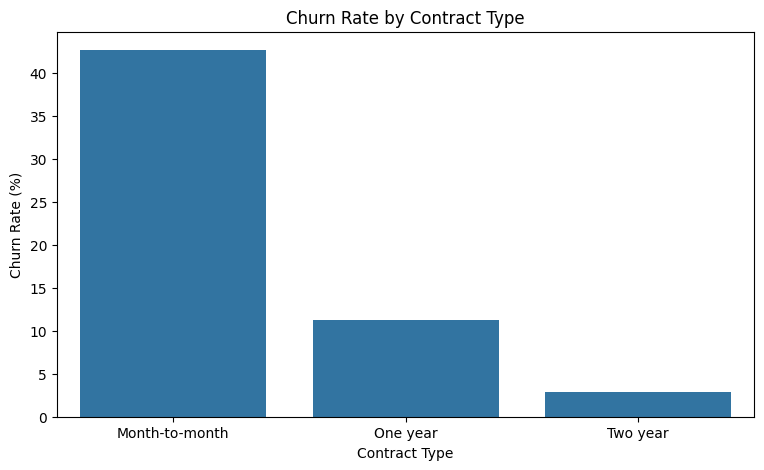

In [ ]:
plt.figure(figsize = (9, 5))

sns.barplot(
    data = contract_churn,
    x = 'Contract',
    y = 'ChurnRate'
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

**Observation:** Based on this analysis, a telecom business could use contract type as an important customer-retention segmentation variable. However, association is not causality. so its save to say customers on longer-term contracts exhibit substantially lower observed churn rates in this dataset.

##### Internet Service Analysis

In [ ]:
# Computing churn
internet_churn = (
    df_churn_clean.groupby('InternetService')['Churn']
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name = 'ChurnRate')
    .sort_values('ChurnRate', ascending=False)
).round(2)

internet_churn

,InternetService,ChurnRate
1,Fiber optic,41.89
0,DSL,18.96
2,No,7.40


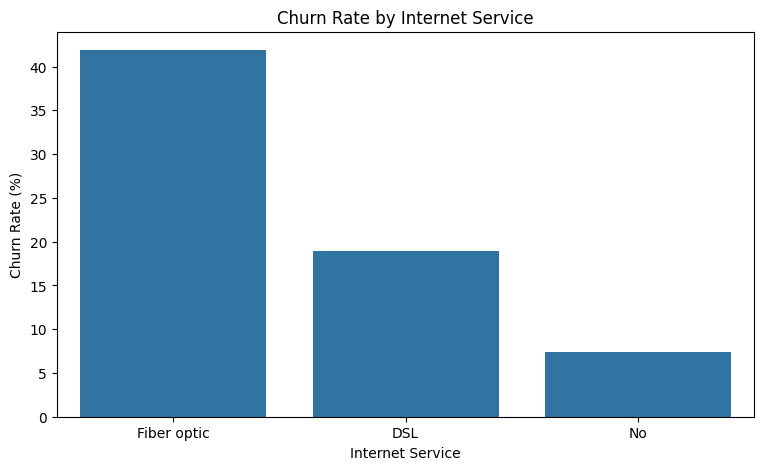

In [ ]:
# Visualize the Churn Rate
plt.figure(figsize = (9, 5))

sns.barplot(
    data = internet_churn,
    x = 'InternetService',
    y = 'ChurnRate'
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.show()

**Observation:** Fiber-optic customers show a considerably higher observed churn rate than the other internet-service groups. This is a good findings because it could potentially interact with - monthly charges, contract type, technical-support services, online-security services, tenure...

##### Payment Method Analysis

In [ ]:
# Computing the churn rate
payment_churn = (
    df_churn_clean.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name = 'ChurnRate')
    .sort_values('ChurnRate', ascending=False)
).round(2)

payment_churn

,PaymentMethod,ChurnRate
2,Electronic check,45.29
3,Mailed check,19.11
0,Bank transfer (automatic),16.71
1,Credit card (automatic),15.24


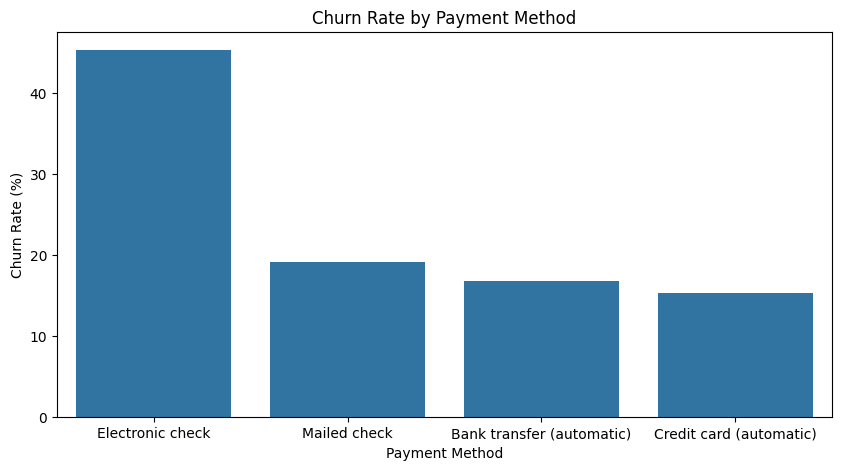

In [ ]:
# Visualizing the Churn Rate
plt.figure(figsize = (10, 5))

sns.barplot(
    data = payment_churn,
    x = 'PaymentMethod',
    y = 'ChurnRate'
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')

plt.show()

**Observation:** Manual payment mode show a considerably higher observed churn rate than the automatic means. However, this is an association, not evidence that payment method itself causes churn.

##### Monthly Charges and Churn Analysis

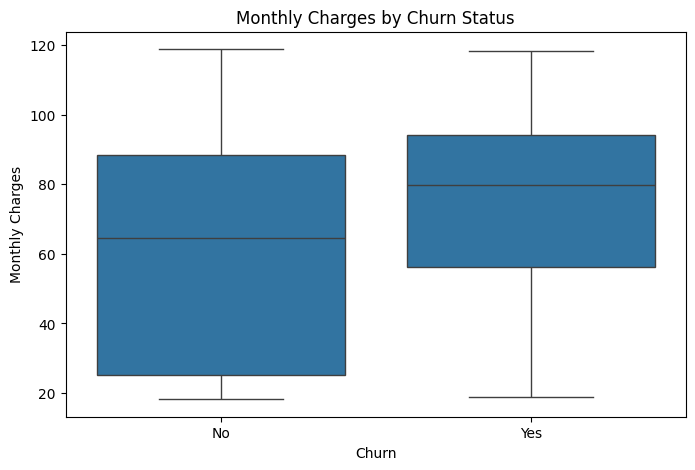

In [ ]:
# Examining the relationship using Boxplot
plt.figure(figsize = (8, 5))

sns.boxplot(
    data = df_churn_clean,
    x = 'Churn',
    y = 'MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

In [ ]:
# Computing the means
df_churn_clean.groupby('Churn')['MonthlyCharges'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


**Observation:** This box plot reveals that higher monthly billing rates are positively correlated with churn, showing that customers who churned generally have significantly higher monthly charges than those who stay.

##### Total Charges and Churn Analysis

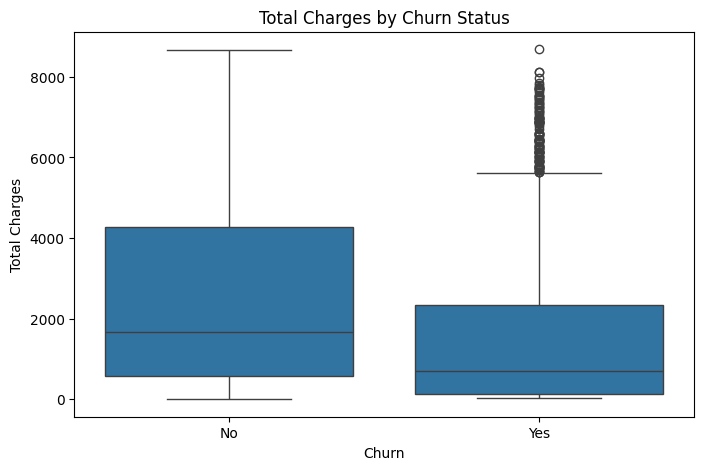

In [ ]:
# Examining the relationship using Boxplot
plt.figure(figsize = (8, 5))

sns.boxplot(
    data = df_churn_clean,
    x = 'Churn',
    y = 'TotalCharges'
)

plt.title('Total Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

In [ ]:
# Computing the means
df_churn_clean.groupby('Churn')['TotalCharges'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,2549.91,1679.52,0.00,8672.45
Yes,1869,1531.80,703.55,18.85,8684.80


**Observation:** Total charges are naturally influenced by how long the customer has been with the company. And we've already established that tenure has a strong relationship with TotalCharges. To this end, we could not interpret a lower average total charge among churners as evidence that lower total spending causes churn.

##### Correlation Analysis

We examine numerical relationships.

In [ ]:
# Computing the correlation
correlation_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

correlation_matrix = df_churn_clean[
    correlation_features
].corr()

correlation_matrix.round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


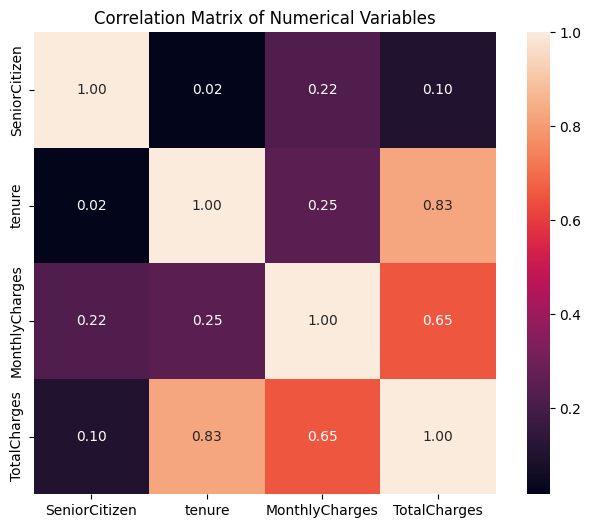

In [ ]:
# Visualizing with Heatmap
plt.figure(figsize = (8, 6))

sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = '.2f',
    square=True
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

**Observations:**

From our analysis:

- tenure ↔ TotalCharges: ~0.83
- MonthlyCharges ↔ TotalCharges: ~0.65

This kind of make business sense as customers who stay longer generally accumulate more charges.

#### EDA Conclusions

**Exploratory Data Analysis Findings**

The exploratory analysis identified several notable patterns in the Telco Customer Churn dataset.

First, the overall churn rate is approximately 26.54%, indicating that churn is a minority outcome and establishing the class imbalance that will need to be considered during classification.

Customer tenure shows a strong observed relationship with churn. Customers in the 0–12 month tenure band have a substantially higher churn rate than customers in longer-tenure bands, while the observed churn rate declines progressively across the longer tenure groups.

Contract type also shows substantial variation in observed churn. Month-to-month customers have a considerably higher churn rate than customers on one-year and two-year contracts.

Internet-service categories also differ in their observed churn rates, with fiber-optic customers exhibiting a higher churn rate than the DSL and no-internet-service groups in this dataset. Payment method shows a similar pattern, with electronic-check customers exhibiting a higher observed churn rate than the other payment categories.

The analysis also shows relationships between numerical variables. Tenure and total charges are strongly positively correlated, which is expected because longer customer relationships provide more opportunity for charges to accumulate. Monthly charges show a positive association with churn, while tenure shows a negative association with churn.

These findings identify potentially important predictors for the subsequent feature-engineering and classification stages. However, the exploratory results represent associations rather than causal relationships. Multivariable machine-learning models will therefore be used to determine whether these variables provide useful predictive information when considered jointly.

## PART 2. FEATURE ENGINEERING AND ENCODING

Feature engineering transforms raw customer attributes into variables that can provide more meaningful information to our analytical models. The objective is to create features that represent meaningful aspects of the customer relationship, usage, tenure, and billing behaviour.

The engineered features will be evaluated for their business relevance and potential redundancy before being included in subsequent clustering and classification analyses.

### Duplicate The Working Dataset

In [ ]:
df_model = df_churn_clean.copy()

print('Shape before feature engineering:', df_model.shape)

Shape before feature engineering: (7043, 22)


**Reason For 22 Columns**

This is because we created TenureBand during our EDA. However, we don't necessarily want TenureBand as a modelling feature. It was created primarily for EDA and business interpretation.

### Feature 1: Tenure in Years

**Business Justification**

The original tenure variable measures the number of months a customer has remained with the business.

A TenureYears feature is created by converting tenure from months into years. This provides a more intuitive representation of customer relationship duration while retaining the underlying information contained in the original tenure variable. This feature may also improve business interpretation because customer-retention strategies are often discussed in terms of customer relationship duration rather than individual months.

In [ ]:
df_model['TenureYears'] = (df_model['tenure'] / 12).round(1)

df_model[['tenure', 'TenureYears']].head()

,tenure,TenureYears
0,1,0.1
1,34,2.8
2,2,0.2
3,45,3.8
4,2,0.2


In [ ]:
# Validation using 'describe()

df_model['TenureYears'].describe().round(1)

,TenureYears
count,7043.0
mean,2.7
std,2.0
min,0.0
25%,0.8
50%,2.4
75%,4.6
max,6.0


The minimum is 0. Recall we identify 11 customers with zero tenure.

The maximum is 6 years because the maximum month in the dataset is 72 months

### Feature 2: Service Count

**Business Justification**

A ServiceCount feature is created to represent the breadth of services actively subscribed to by each customer. The feature counts the number of service variables with an explicit 'Yes' response.

The purpose is to provide a compact measure of service adoption that may capture differences between customers with relatively simple service relationships and customers with broader service usage.

In [ ]:
service_features = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df_model['ServiceCount'] = (
    df_model[service_features] == 'Yes'
).sum(axis = 1)

df_model[
    ['customerID'] + service_features + ['ServiceCount']
].head()

,customerID,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceCount
0,7590-VHVEG,No,No phone service,No,Yes,No,No,No,No,1
1,5575-GNVDE,Yes,No,Yes,No,Yes,No,No,No,3
2,3668-QPYBK,Yes,No,Yes,Yes,No,No,No,No,3
3,7795-CFOCW,No,No phone service,Yes,No,Yes,Yes,No,No,3
4,9237-HQITU,Yes,No,No,No,No,No,No,No,1


In [ ]:
# Check the Distribution

df_model['ServiceCount'].value_counts().sort_index()

,count
ServiceCount,
0,80
1,1701
2,1188
3,965
4,922
5,908
6,676
7,395
8,208


In [ ]:
# Validation using 'describe()

df_model['ServiceCount'].describe().round(0)

,ServiceCount
count,7043.0
mean,3.0
std,2.0
min,0.0
25%,1.0
50%,3.0
75%,5.0
max,8.0


We have more customers enrolled for 1 service followed closed by customers enrolled for 2 services.

### Feature 3: Average Monthly Spend to Date

**Business Justification**

We could not compute this using TotalCharges/tenure because of those customers with zero tenure and also the ratio will be related to MonthlyCharges which will carry little information. Instead, we created  a spending-to-date relative to monthly charge feature.

A **ChargeMonth** feature is created by dividing cumulative TotalCharges by the customer's current MonthlyCharges. This represents the customer's accumulated charges in terms of current monthly-charge equivalents. It provides an additional perspective on the customer's cumulative billing relationship while remaining interpretable in business terms.

In [ ]:
# Investigating the Denominator

print((df_model['MonthlyCharges'] == 0).sum())
print('Since the output is zero, the division by MonthlyCharges is safe')

0
Since the output is zero, the division by MonthlyCharges is safe


In [ ]:
df_model['ChargeMonths'] = (
    df_model['TotalCharges'] / df_model['MonthlyCharges']
).round(0)

df_model['ChargeMonths'].describe().round(0)

,ChargeMonths
count,7043.0
mean,32.0
std,25.0
min,0.0
25%,9.0
50%,29.0
75%,55.0
max,79.0


In [ ]:
df_model[
    [
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'ChargeMonths'
    ]
].head(10)

,tenure,MonthlyCharges,TotalCharges,ChargeMonths
0,1,29.85,29.85,1.0
1,34,56.95,1889.50,33.0
2,2,53.85,108.15,2.0
3,45,42.30,1840.75,44.0
4,2,70.70,151.65,2.0
5,8,99.65,820.50,8.0
6,22,89.10,1949.40,22.0
7,10,29.75,301.90,10.0
8,28,104.80,3046.05,29.0
9,62,56.15,3487.95,62.0


#### Feature Engineering Check

We investigates the relationship between our new features and the original numerical variables.

In [ ]:
feature_corr = df_model[
    ['tenure',
        'TenureYears',
        'MonthlyCharges',
        'TotalCharges',
        'ChargeMonths',
        'ServiceCount']
    ].corr()

feature_corr.round(2)

,tenure,TenureYears,MonthlyCharges,TotalCharges,ChargeMonths,ServiceCount
tenure,1.00,1.00,0.25,0.83,1.00,0.52
TenureYears,1.00,1.00,0.25,0.83,1.00,0.52
MonthlyCharges,0.25,0.25,1.00,0.65,0.25,0.80
TotalCharges,0.83,0.83,0.65,1.00,0.83,0.80
ChargeMonths,1.00,1.00,0.25,0.83,1.00,0.52
ServiceCount,0.52,0.52,0.80,0.80,0.52,1.00


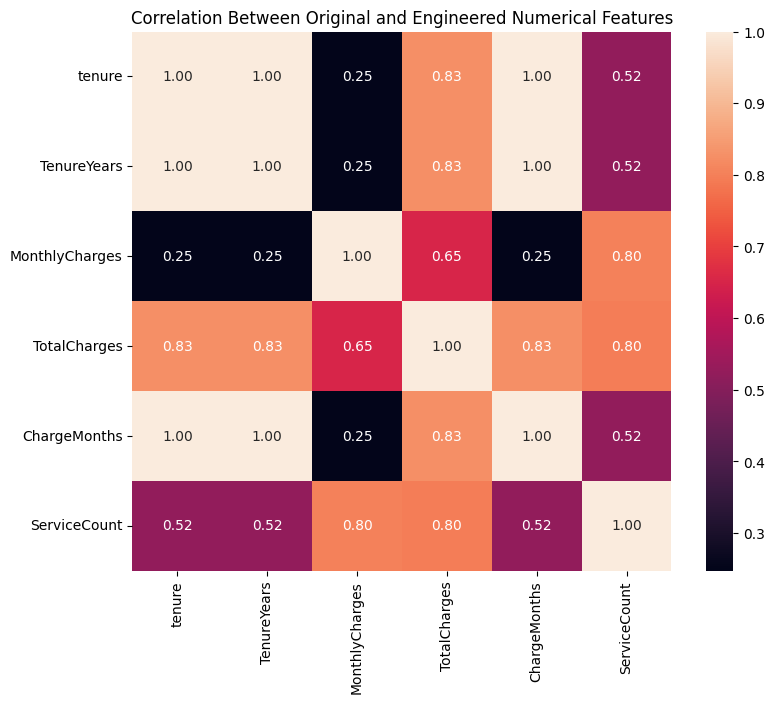

In [ ]:
# Visualizing the correlation

plt.figure(figsize = (9, 7))

sns.heatmap(
    feature_corr,
    annot = True,
    fmt = '.2f',
    square = True
)

plt.title('Correlation Between Original and Engineered Numerical Features')

plt.show()

**Why the Check**

We did this investigation because we know that feature engineering can accidentally create redundant variables.

For example:

TenureYears = tenure / 12 is mathematically derived from tenure. Therefore, we don't necessarily need both variables in every model. We will decide for classification model whether the original tenure or TenureYears provides the more useful representation.

For clustering, we need to be careful as well  because redundant variables can effectively give one underlying concept excessive influence.

In [ ]:
# Summary of the Engineered Features

engineered_features = [
    'TenureYears',
    'ServiceCount',
    'ChargeMonths'
]

df_model[engineered_features].describe().round(2)

,TenureYears,ServiceCount,ChargeMonths
count,7043.00,7043.00,7043.00
mean,2.70,3.36,32.37
std,2.05,2.06,24.60
min,0.00,0.00,0.00
25%,0.80,1.00,9.00
50%,2.40,3.00,29.00
75%,4.60,5.00,55.00
max,6.00,8.00,79.00


In [ ]:
# Check for Missing Values

df_model[engineered_features].isna().sum()

,0
TenureYears,0
ServiceCount,0
ChargeMonths,0


#### Feature Retention Decision

**TenureBand** was created during exploratory analysis to make churn differences across customer-tenure groups easier to communicate. However, it is a discretized representation of the original tenure variable and therefore introduces redundancy if both variables are used as predictive features.

It will be retained for exploratory and business reporting purposes but excluded from the machine-learning feature matrix.

### Encoding of All Categorical Columns

#### Encoding the Target

The target variable **Churn** is encoded as a binary variable, where 1 represents a customer who churned (Yes) and 0 represents a customer who remained (No).

The positive class is therefore explicitly defined as churn because the subsequent classification analysis focuses on identifying customers at risk of leaving.

In [ ]:
# Churn Mapping

df_model['ChurnBinary'] = (
    df_model['Churn']
        .map({'No': 0, 'Yes': 1})
)

df_model[['Churn', 'ChurnBinary']].head()

,Churn,ChurnBinary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [ ]:
# Check
df_model['ChurnBinary'].value_counts()

,count
ChurnBinary,
0,5174
1,1869


#### Identifying Categorical Features

In [ ]:
categorical_features = df_model.select_dtypes(
    include = 'object'
).columns.tolist()

categorical_features

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

The above is the list of all categorical columns in the dataset. However, we do not need every columns hence why there will be expulsion of some features.

#### Removing Identifier and Target

In [ ]:
exclude_from_features = [
     'customerID',
    'Churn',
    'ChurnBinary',
    'TenureBand'
]

categorical_features = [
    col for col in categorical_features
    if col not in exclude_from_features
]

categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

For proper documentation we adopt the above approach which is much safer than simply dropping columns.

#### Numerical Features
Defining the numerical variables we'll consider.

In [ ]:
numerical_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ServiceCount',
    'ChargeMonths'
]

numerical_features

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'ServiceCount',
 'ChargeMonths']

We're not using both tenure and TenureYears. Since they're mathematically equivalent, keeping both would unnecessarily duplicate the same underlying information. We'll use **tenure** because it is the original observed variable and retains the dataset's native measurement. That means **TenureYears** remains useful for business interpretation but doesn't need to enter the model.

Also, even though **ChargeMonths** satisfies the requirement for an engineered feature, we won't blindly use it in the final model because its derived from TotalCharges & MonthlyCharges and TotalCharges is strongly influenced by tenure.

**So we will test its usefulness rather than assume it improves the model. Feature engineering creates candidates. Model evaluation determines whether they earn a place in the final feature set.**

#### One-Hot Encoding

We have categorical variables which are strings. Machine-learning algorithms can't directly work with strings. Therefore, We'll use **One-Hot Encoding**

**Constraint:** Encode the entire dataset before splitting it.

We should not encode the entire dataset before splitting it, because preprocessing should be learned from the training data, not the entire dataset. Otherwise, information from the test set can influence preprocessing. That's a form of data leakage.

**So we're going to use a Pipeline/ColumnTransformer approach later.**

#### Preparing the Feature Matrix
Basically defining x and y.

In [ ]:
x = df_model[
    numerical_features + categorical_features
    ].copy()

y = df_model['ChurnBinary'].copy()

print('Feature matrix shape:', x.shape)
print('Target shape:', y.shape)

Feature matrix shape: (7043, 21)
Target shape: (7043,)


In [ ]:
# Checking Feature Composition

print('Numerical features:')
for feature in numerical_features:
    print('-', feature)

print('\nCategorical features:')
for feature in categorical_features:
    print('-', feature)

Numerical features:
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges
- ServiceCount
- ChargeMonths

Categorical features:
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod


#### Feature Engineering Quality Check

In [ ]:
feature_quality = pd.DataFrame({
    'Feature': x.columns,
    'Data_Type': x.dtypes.astype(str).values,
    'Missing_Values': x.isna().sum().values,
    'Unique_Values': x.nunique().values
})

feature_quality

,Feature,Data_Type,Missing_Values,Unique_Values
0,SeniorCitizen,int64,0,2
1,tenure,int64,0,73
2,MonthlyCharges,float64,0,1585
3,TotalCharges,float64,0,6531
4,ServiceCount,int64,0,9
5,ChargeMonths,float64,0,79
6,gender,object,0,2
7,Partner,object,0,2
8,Dependents,object,0,2
9,PhoneService,object,0,2


#### Create the 70/15/15 split in Preparation for Preprocessing

To support reliable model development and evaluation, the dataset was divided into three subsets: 70% training, 15% validation, and 15% testing. A stratified split was used so that the proportion of churned and non-churned customers remains approximately consistent across all three subsets.

The training set will be used to fit the machine-learning models and perform cross-validation. The validation set will be used for model selection and decisions such as classification-threshold tuning. The test set will remain completely untouched during model development and will only be used for the final evaluation of the selected model. This approach helps reduce the risk of obtaining overly optimistic performance estimates and provides a more reliable assessment of how the final model may perform on previously unseen customers.

All preprocessing steps, including scaling and categorical encoding, will be fitted using the training data only and subsequently applied to the validation and test sets. This prevents information from the validation or test sets from leaking into the model-development process.

In [ ]:
# First split: 85% development data, 15% untouched test data
x_dev, x_test, y_dev, y_test = train_test_split(
    x,
    y,
    test_size = 0.15,
    random_state = 42,
    stratify = y
)

# Second split: divide the 85% development data into approximately 70% training and 15% validation of the full dataset
x_train, x_val, y_train, y_val = train_test_split(
    x_dev,
    y_dev,
    test_size = 0.1765,
    stratify = y_dev,
    random_state = 42
)

print('Dataset split completed.\n')

print(f'Training set:   {x_train.shape[0]:,} rows')
print(f'Validation set: {x_val.shape[0]:,} rows')
print(f'Test set:       {x_test.shape[0]:,} rows')

Dataset split completed.

Training set:   4,929 rows
Validation set: 1,057 rows
Test set:       1,057 rows


#### Verifying that the stratification worked
This is important because churn is our target and only about 26.5% of customers churned.

In [ ]:
split_summary = pd.DataFrame({
    'Dataset' : ['Full Dataset', 'Train', 'Validation', 'Test'],
    'Record' : [
        len(y),
        len(y_train),
        len(y_val),
        len(y_test)
    ],
    'Churned' : [
        y.sum(),
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    'Churned Rate' : [
        y.mean(),
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

split_summary

,Dataset,Record,Churned,Churned Rate
0,Full Dataset,7043,1869,0.265370
1,Train,4929,1308,0.265368
2,Validation,1057,281,0.265847
3,Test,1057,280,0.264901


The churn rates are very close to one another, around 26.5%. This gives us evidence that the three datasets have comparable target distributions.

#### Building Preprocessing Pipeline

The dataset contains both numerical and categorical predictors, so separate preprocessing strategies are required.

**Numerical variables will be standardized using StandardScaler** so that variables measured on different scales do not disproportionately influence algorithms that are sensitive to feature magnitude.

**Categorical variables will be transformed using one-hot encoding.** This converts categorical values into numerical indicator variables while avoiding an artificial ordering between categories.

The **preprocessing will be implemented using a ColumnTransformer and fitted only on the training data.** The same fitted transformations will then be applied to the validation and test sets. This prevents information from the validation and test datasets from influencing the preprocessing parameters used during model development.

#### Create the ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown = 'ignore',
                sparse_output = False
            ),
            categorical_features
        )
    ]
)

#### Fit ONLY on Training Data

We do this to explicitly prevent preprocessing leakage.

In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)

x_val_processed = preprocessor.transform(x_val)

x_test_processed = preprocessor.transform(x_test)

We do not use [preprocessor.fit_transform(X)] because that would allow information from the validation and test observations to influence the preprocessing.

#### Checking the Resulting Dimensions

In [ ]:
print('Original training features:', x_train.shape)
print('Processed training features:', x_train_processed.shape)

print('Original validation features:', x_val.shape)
print('Processed validation features:', x_val_processed.shape)

print('Original test features:', x_test.shape)
print('Processed test features:', x_test_processed.shape)

Original training features: (4929, 21)
Processed training features: (4929, 47)
Original validation features: (1057, 21)
Processed validation features: (1057, 47)
Original test features: (1057, 21)
Processed test features: (1057, 47)


The processed feature count is considerably larger than the original number because categorical variables have been converted into multiple binary columns.

#### Verifying the Preprocessing

In [ ]:
pd.DataFrame(
    x_train_processed
).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46
0,-0.434247,1.195612,-0.151233,0.642800,0.299214,1.193326,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.434247,1.114680,-0.494883,0.342677,-0.181029,1.193326,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.434247,0.831419,-0.119842,0.469288,-0.181029,0.910597,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,2.302839,0.426760,-0.303232,0.023461,0.299214,0.385528,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.434247,1.600271,0.273374,1.306470,1.259699,1.597226,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# Validating our preprocessing
numeric_indices = preprocessor.output_indices_['num']

x_train_processed[:, numeric_indices].mean(axis = 0)

array([-3.83115915e-16, -2.29747917e-18, -2.07629049e-16,  1.95803789e-16,
        8.41508058e-17,  2.74796529e-18])

In [ ]:
x_train_processed[:, numeric_indices].std(axis=0)

array([1., 1., 1., 1., 1., 1.])

**Preprocessing validation:**

The numerical features in the training set have means approximately equal to zero after standardization, with differences in the order of (10^-16), which are attributable to floating-point precision. The standard deviation check returns approximately 1. This confirms that the numerical variables were successfully standardized and preprocessing is working correctly

#### Recover the Encoded Feature Names

In [ ]:
feature_names = preprocessor.get_feature_names_out()

print(f'Number of processed features: {len(feature_names)}')

pd.DataFrame({
    'Feature': feature_names
}).head(30)

Number of processed features: 47


,Feature
0,num__SeniorCitizen
1,num__tenure
2,num__MonthlyCharges
3,num__TotalCharges
4,num__ServiceCount
5,num__ChargeMonths
6,cat__gender_Female
7,cat__gender_Male
8,cat__Partner_No
9,cat__Partner_Yes


#### Quick Preprocessing Checkpoint

In [ ]:
print('===== PREPROCESSING CHECKPOINT =====')
print(f'Training Observations:   {x_train_processed.shape[0]:,}')
print(f'Validation Observations: {x_val_processed.shape[0]:,}')
print(f'Test Observations:       {x_test_processed.shape[0]:,}')
print(f'Processed Features:      {x_train_processed.shape[1]:,}')
print(f'Missing Values in Train: {np.isnan(x_train_processed).sum():,}')
print(f'Missing Values in Val:   {np.isnan(x_val_processed).sum():,}')
print(f'Missing Values in Test:  {np.isnan(x_test_processed).sum():,}')

===== PREPROCESSING CHECKPOINT =====
Training Observations:   4,929
Validation Observations: 1,057
Test Observations:       1,057
Processed Features:      47
Missing Values in Train: 0
Missing Values in Val:   0
Missing Values in Test:  0


## Part 3: Clustering Analysis

The objective of the clustering analysis is to identify naturally occurring customer segments based on customer characteristics, service adoption, tenure, and billing behaviour.

K-Means clustering will be used to group customers with similar characteristics. The target variable, ChurnBinary, will not be included in the clustering process because the purpose of clustering is to discover customer segments independently of the known churn outcome.

The analysis will evaluate values of K from 2 to 10 using both the elbow method and silhouette scores. The selected number of clusters will then be used to profile the resulting customer segments.

#### Preparing Clustering Dataset

In [ ]:
clustering_features = numerical_features + categorical_features

x_cluster = df_model[clustering_features].copy()

print('Clustering dataset shape:', x_cluster.shape)
print('Churn included:', 'ChurnBinary' in x_cluster.columns)
print('Customer ID included:', 'customerID' in x_cluster.columns)
print('Tenure Band included:', 'TenureBand' in x_cluster.columns)

Clustering dataset shape: (7043, 21)
Churn included: False
Customer ID included: False
Tenure Band included: False


We are deliberate about the feature selection for the clustering because we want to discover clusters without the knowledge of whether the customer churned.

#### Preprocessing The Clustering Variables

**K-Means** clustering is distance-based, meaning that variables with larger numerical scales can exert greater influence on the resulting clusters. To avoid this, **numerical variables will be standardized before clustering.**

**Categorical variables will be converted into numerical indicator variables using one-hot encoding.** The clustering dataset excludes ChurnBinary, Churn, and customerID so that the customer segments are generated from customer characteristics rather than the target outcome or identifier.

The resulting feature matrix will therefore contain standardized numerical characteristics and encoded categorical characteristics suitable for K-Means clustering.

In [ ]:
cluster_preprocessor = ColumnTransformer(
    transformers = [
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown = 'ignore',
                sparse_output = False
            ),
            categorical_features
        )
    ]
)

#### Transforming the Complete Clustering Dataset

In [ ]:
x_cluster_processed = cluster_preprocessor.fit_transform(x_cluster)

print('Original clustering data:', x_cluster.shape)
print('Processed clustering data:', x_cluster_processed.shape)

Original clustering data: (7043, 21)
Processed clustering data: (7043, 47)


**Note:** We fit the clustering preprocessing on the complete clustering dataset because this is unsupervised exploratory analysis. We're not using a held-out test set to claim predictive performance.

#### Run K-Means for K = 2 to 10

We'll calculate:

- Inertia - for the elbow method

- Silhouette score - for cluster separation

In [ ]:
k_values = range(2, 11)

inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    cluster_labels = kmeans.fit_predict(x_cluster_processed)

    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(x_cluster_processed, cluster_labels)
    )

In [ ]:
clustering_result = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia_scores,
    'Silhouette Score' : silhouette_scores
})

clustering_result.sort_values(
    by = 'Silhouette Score',
    ascending = False
)

,K,Inertia,Silhouette Score
1,3,61207.240445,0.254489
2,4,56770.351990,0.234634
0,2,77886.809078,0.217739
3,5,53551.128586,0.203143
4,6,50616.197954,0.182632
6,8,45911.326276,0.173409
5,7,48058.504043,0.169106
7,9,44585.573739,0.167324
8,10,43642.829404,0.149247


#### Elbow Curve

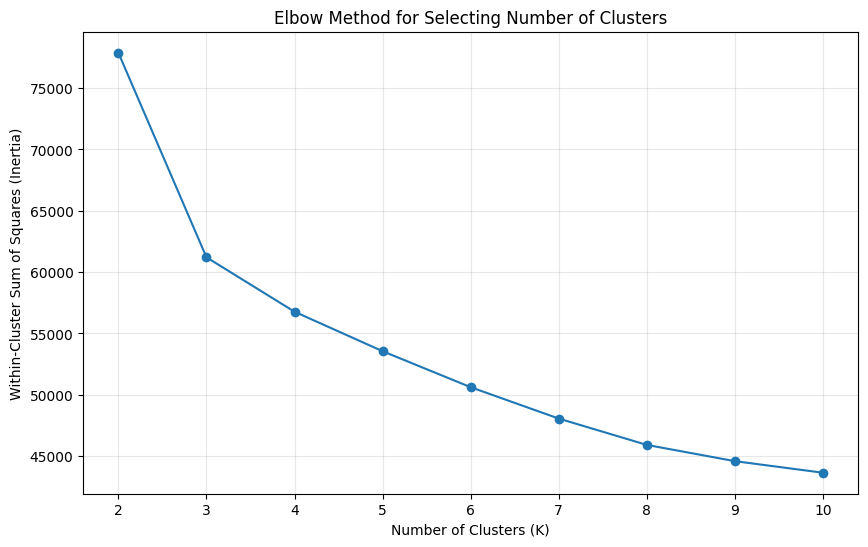

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(
    clustering_result['K'],
    clustering_result['Inertia'],
    marker = 'o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Method for Selecting Number of Clusters')
plt.xticks(list(k_values))
plt.grid(alpha = 0.3)

plt.show()

**Key Insight**

**The Elbow Inflection Point (K = 3)**: As we move from K = 2 to K = 3, there is a massive, sharp drop in the Within-Cluster Sum of Squares (Inertia) from nearly 78,000 down to roughly 61,000. This indicates that moving to 3 clusters captures a massive amount of structure in our data.

However, we will not select K from the elbow alone. That's why we also calculated the silhouette score.

#### Silhouette Score

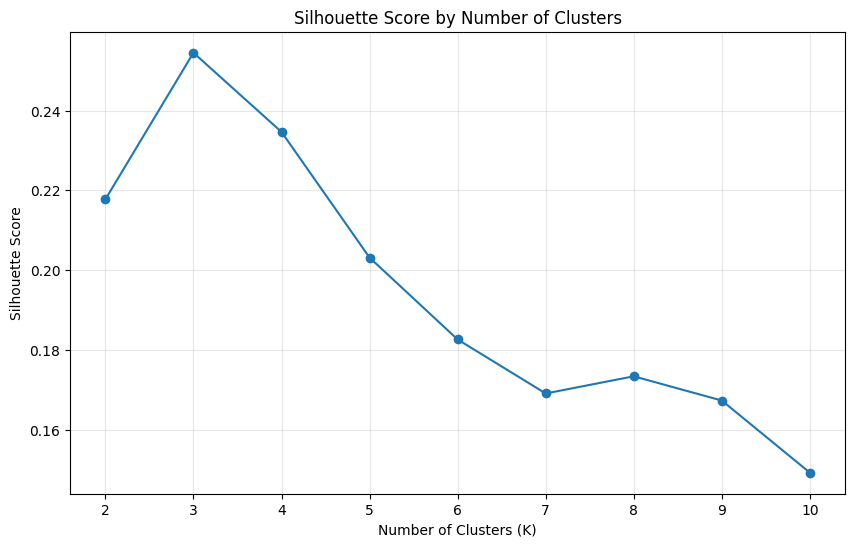

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(
    clustering_result['K'],
    clustering_result['Silhouette Score'],
    marker="o"
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.xticks(list(k_values))
plt.grid(alpha = 0.3)

plt.show()

**Key Insight**

**The Global Maximum (K = 3):** The silhouette score reaches its absolute peak here at approximately 0.255. This confirms that dividing your customers into 3 clusters provides the best possible balance between tight intra-cluster distance and wide inter-cluster separation.

#### Selecting the Number of Clusters

The elbow method and silhouette analysis were considered jointly to determine an appropriate number of customer clusters.

The **elbow curve** shows a pronounced reduction in inertia when moving from K=2 to K=3, after which the incremental reduction in within-cluster variation becomes considerably smaller. This indicates that three clusters capture a substantial amount of the structure in the customer data without introducing a large number of increasingly smaller improvements.

The **silhouette analysis** provides additional support for this choice. Among the evaluated values from K=2 to K=10, K=3 produces the **highest silhouette score of 0.2545.** Although the score indicates moderate separation rather than highly distinct clusters, the combination of the elbow pattern and the highest silhouette score provides a reasonable basis for selecting three clusters.

Therefore, **K=3 will be used for the final K-Means segmentation.** The resulting clusters will subsequently be profiled to assess whether they represent meaningful and interpretable customer segments.

#### Fit the Final K-Means Model

In [ ]:
final_k = 3

kmeans_final = KMeans(
    n_clusters = final_k,
    random_state = 42,
    n_init = 10
)

cluster_labels = kmeans_final.fit_predict(x_cluster_processed)

df_model['Cluster'] = cluster_labels

cluster_distribution = (
    df_model['Cluster']
    .value_counts()
    .sort_index()
    .rename('Customers')
    .to_frame()
)

cluster_distribution['Percentage'] = (
    cluster_distribution['Customers'] /
    len(df_model) * 100
).round(2)

cluster_distribution

,Customers,Percentage
Cluster,,
0,2394,33.99
1,1526,21.67
2,3123,44.34


#### Profiling the Clusters

This is important because we want the clusters to be more useful from a business perspective.

In [ ]:
# numerical characteristics

cluster_numeric_profile = (
    df_model
    .groupby('Cluster')[numerical_features]
    .mean()
    .round(2)
)

cluster_numeric_profile

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,ChargeMonths
Cluster,,,,,,
0,0.20,56.57,88.50,4999.70,5.53,56.60
1,0.03,30.55,21.08,662.60,1.22,30.56
2,0.20,14.72,67.91,984.87,2.75,14.68


In [ ]:
# Categorical Cluster Profiles

cluster_categorical_profile = {}

for feature in categorical_features:
    profile = pd.crosstab(
        df_model['Cluster'],
        df_model[feature],
        normalize = 'index'
    ) * 100

    cluster_categorical_profile[feature] = profile.round(2)

cluster_categorical_profile['Contract']

Contract,Month-to-month,One year,Two year
Cluster,,,
0,25.77,33.12,41.10
1,34.34,23.85,41.81
2,87.54,10.12,2.34


**Inspecting on the other important categorical dimensions**

In [ ]:
cluster_categorical_profile['InternetService']

InternetService,DSL,Fiber optic,No
Cluster,,,
0,40.02,59.98,0.0
1,0.00,0.00,100.0
2,46.85,53.15,0.0


In [ ]:
cluster_categorical_profile['PaymentMethod']

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Cluster,,,,
0,31.79,30.58,29.24,8.40
1,21.76,21.69,7.99,48.56
2,14.44,14.70,49.41,21.45


In [ ]:
cluster_categorical_profile['TechSupport']

TechSupport,No,No internet service,Yes
Cluster,,,
0,42.48,0.0,57.52
1,0.00,100.0,0.00
2,78.64,0.0,21.36


In [ ]:
cluster_categorical_profile['OnlineSecurity']

OnlineSecurity,No,No internet service,Yes
Cluster,,,
0,45.41,0.0,54.59
1,0.00,100.0,0.00
2,77.20,0.0,22.80


#### Compact Overview of What Characterizes each Cluster

Rather than manually looking at every categorical variable, let's automatically identify the dominant category for each cluster.

In [ ]:
dominant_categories = []

for cluster in sorted(df_model['Cluster'].unique()):

    row = {'Cluster': cluster}

    for feature in categorical_features:
        proportions = (
            df_model[df_model['Cluster'] == cluster][feature]
            .value_counts(normalize=True)
        )

        row[feature] = proportions.idxmax()

    dominant_categories.append(row)

dominant_category_df = pd.DataFrame(dominant_categories)

dominant_category_df

,Cluster,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,Male,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)
1,1,Male,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
2,2,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check


#### Summary of Cluster Profilling & Segment Name

These are descriptive labels based on observed cluster characteristics, not claims about customer motivation.

| Cluster | Size | Key characteristics | Descriptive Name | Evidence |
|---|---|---|---|---|
| 0 | 33.99% | Very high tenure, high monthly/total charges, highest service adoption, fiber optic, two-year contracts, multiple services | Established, High-Value Customers | 56.6-month average tenure, 88.5 monthly charge, 4,999.7 total charges, 5.53 services, broad service adoption |
| 1 | 21.67% |Very low monthly/total charges, low service adoption, no internet service, low senior-citizen proportion | Basic / Non-Internet Customers | 100% no internet, 21.1 monthly charge, 662.6 total charges, 1.22 services, 48.56% mailed-check |
| 2 | 44.34% | Shorter tenure, moderate-high monthly charges, fiber optic, month-to-month contracts, limited add-on services | Newer, Flexible-Service Customers | 14.7-month tenure, 67.9 monthly charge, month-to-month dominant, 2.75 services, high electronic-check usage |

**Cluster Profile Interpretation**

The K-Means model produced three customer segments with different demographic, tenure, service, and billing characteristics.

**Cluster 0: Established, High-Value Customers**

Cluster 0 contains approximately 34.0% of customers. These customers have the highest average tenure at approximately 56.6 months, the highest average monthly charge at approximately 88.5, and the highest average total charges at approximately 4,999.7. They also have the highest average service count at approximately 5.5 services per customer. The dominant characteristics include fiber-optic internet, multiple lines, several additional services, two-year contracts, paperless billing, and automatic bank-transfer payments. Overall, this segment represents customers with relatively long relationships with the company and broad service adoption.

**Cluster 1: Basic / Non-Internet Customers**

Cluster 1 represents approximately 21.7% of customers and has the lowest average monthly charge at approximately 21.1 and the lowest average total charges at approximately 662.6. Average tenure is approximately 30.6 months, while average service count is only 1.2. The dominant characteristics include no internet service, no additional internet-related services, no multiple lines, mailed-check payment, and no paperless billing. This segment therefore represents customers with relatively limited service adoption and lower billing values.

**Cluster 2: Newer, Flexible-Service Customers**

Cluster 2 is the largest segment, representing approximately 44.3% of customers. Its average tenure is approximately 14.7 months, substantially below Cluster 0. However, its average monthly charge is approximately 67.9, indicating relatively higher monthly billing despite the shorter customer relationship. The dominant characteristics include fiber-optic internet, month-to-month contracts, electronic-check payments, paperless billing, and limited adoption of additional services such as online security, backup, device protection, and technical support.

These profiles show that the clustering algorithm has identified segments that differ substantially in tenure, service adoption, and billing characteristics.

#### Running PCA

In [ ]:
pca = PCA(n_components = 2, random_state = 42)

x_cluster_pca = pca.fit_transform(x_cluster_processed)

print('Original dimensions:', x_cluster_processed.shape[1])
print('PCA dimensions:', x_cluster_pca.shape[1])

print(
    'Explained variance by PC1 and PC2:',
    pca.explained_variance_ratio_
)

print(
    'Total explained variance:',
    pca.explained_variance_ratio_.sum()
)

Original dimensions: 47
PCA dimensions: 2
Explained variance by PC1 and PC2: [0.32297667 0.18471348]
Total explained variance: 0.5076901507645563


The two-dimensional PCA projection captures 50.77% of the variance in the processed clustering dataset, providing a useful two-dimensional representation of the customer segments while acknowledging that some information from the original feature space is not represented in the plot.

##### Create the PCA Dataset

In [ ]:
pca_df = pd.DataFrame({
    'PC1': x_cluster_pca[:, 0],
    'PC2': x_cluster_pca[:, 1],
    'Cluster': cluster_labels
})

pca_df['Cluster Name'] = pca_df['Cluster'].map({
    0: 'Established, High-Value Customers',
    1: 'Basic / Non-Internet Customers',
    2: 'Newer, Flexible-Service Customers'
})

pca_df.head()

,PC1,PC2,Cluster,Cluster Name
0,-2.280411,-1.360516,2,"Newer, Flexible-Service Customers"
1,-0.462819,0.025321,2,"Newer, Flexible-Service Customers"
2,-1.767629,-1.384072,2,"Newer, Flexible-Service Customers"
3,-0.039495,0.653015,2,"Newer, Flexible-Service Customers"
4,-2.024740,-2.205720,2,"Newer, Flexible-Service Customers"


##### Visualizing the PCA

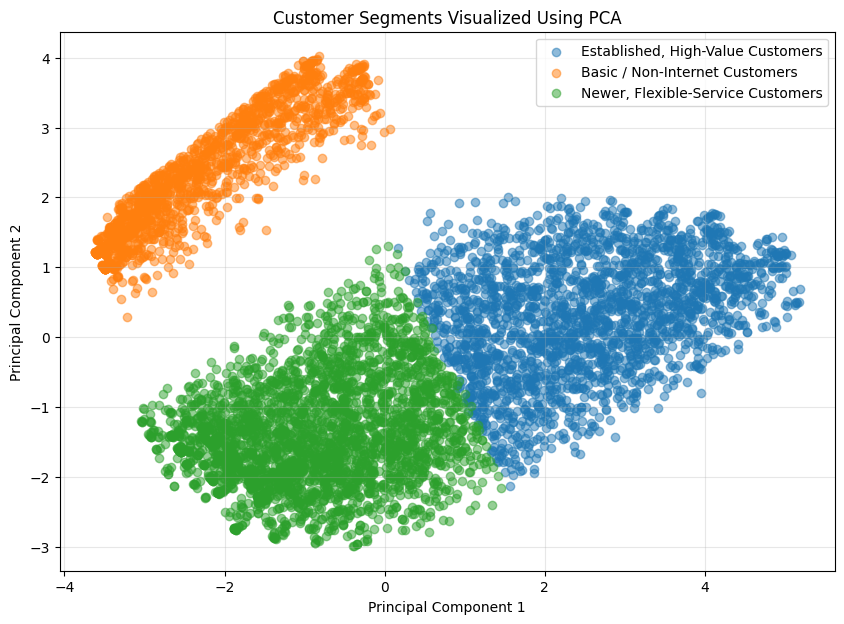

In [ ]:
plt.figure(figsize = (10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label = cluster_data['Cluster Name'].iloc[0],
        alpha = 0.5
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments Visualized Using PCA')
plt.legend()
plt.grid(alpha = 0.3)

plt.show()

**Principal Component Analysis (PCA)** was used to project the high-dimensional clustering dataset into two dimensions for visualization. The PCA plot provides a visual representation of how the three K-Means segments are distributed in the reduced feature space. The PCA visualization is interpreted as a projection rather than a complete representation of the original feature space. Some overlap between clusters is therefore expected because the original clustering was performed using the full set of processed features.

The visualization complements the numerical cluster profiles by showing the relative positioning and separation of the three customer segments in two dimensions.

#### Part 3: Conclusion

The clustering analysis evaluated K-Means solutions from K=2 through K=10 using both the elbow method and silhouette scores. The elbow analysis showed a substantial reduction in within-cluster variation when moving from K=2 to K=3, while the silhouette score reached its highest value of 0.2545 at K=3. Based on the combined evidence, three clusters were selected. The resulting segments differ substantially in tenure, billing levels, service adoption, internet service, and payment behaviour.

**Cluster 0 - Established, High-Value Customers:** approximately 34.0% of customers, characterized by high tenure, high monthly and total charges, and broad service adoption.
**Cluster 1 - Basic / Non-Internet Customers:** approximately 21.7% of customers, characterized by no internet service, low monthly and total charges, and limited service adoption.
**Cluster 2 - Newer, Flexible-Service Customers:** approximately 44.3% of customers, characterized by shorter tenure, relatively higher monthly charges, month-to-month contracts, and lower adoption of additional services.

**PCA** was used to visualize the three clusters in two dimensions. The first two principal components explain approximately 50.77% of the variance in the processed clustering dataset. The PCA visualization therefore provides a useful two-dimensional representation of the segmentation while recognizing that some information from the original feature space is not represented.

## Part 4: Classification

**Objective**

The objective of the classification analysis is to develop a predictive model that can identify customers who are likely to churn. The target variable is **ChurnBinary**, where 1 represents a customer who churned and 0 represents a customer who did not churn.

Four classification algorithms will be evaluated:

- **Logistic Regression**: Useful because it provides a relatively interpretable linear baseline and probability estimates.

- **Decision Tree**: Useful because it can capture non-linear relationships and interaction patterns without requiring linear assumptions.

- **Random Forest**: Useful because it combines multiple decision trees and can capture more complex relationships while generally being more robust than a single tree.

- **Gradient Boosting**: Useful because it builds sequential trees that focus on correcting previous errors and can model complex relationships between customer characteristics and churn.

A **stratified DummyClassifier will also be included as a baseline.** The dummy model provides a reference point against which the predictive models can be assessed. Model performance will be evaluated using Accuracy, Precision, Recall, F1 score, and ROC AUC, together with confusion matrices.

The **test dataset** will remain untouched during model development and model selection. It will only be used for the final evaluation of the selected model.

#### Confirm our Target Distribution

In [ ]:
print('Target Distribution:')
print(y.value_counts())

print('\nTarget percentage:')
print((y.value_counts(normalize = True)* 100).round(2))

Target Distribution:
ChurnBinary
0    5174
1    1869
Name: count, dtype: int64

Target percentage:
ChurnBinary
0    73.46
1    26.54
Name: proportion, dtype: float64


#### Recreate the Preprocessing Inside a Pipeline

In [ ]:
classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown = 'ignore',
                sparse_output = False
            ),
            categorical_features
        )
    ]
)

#### Define the Model

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(
        max_iter = 1000,
        random_state = 42
        ),
    'Decision Tree' : DecisionTreeClassifier(
        random_state = 42
        ),
    'Random Forest' : RandomForestClassifier(
        n_estimators = 200,
        random_state = 42,
        n_jobs = -1
        ),
    'Gradient Boosting' : GradientBoostingClassifier(
        random_state = 42
        )
}

#### Build Pipeline for each Model

In [ ]:
model_pipeline = {}

for name, model in models.items() :
    model_pipeline[name] = Pipeline([
        ('preprocessing', classification_preprocessor),
        ('classifier', model)
    ])

In [ ]:
model_pipeline.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

#### Establish the DummyClassifier Baseline

In [ ]:
dummy_model = DummyClassifier(
    strategy = 'stratified',
    random_state = 42
)

dummy_model.fit(x_train, y_train)

dummy_val_predict = dummy_model.predict(x_val)
dummy_val_proba = dummy_model.predict_proba(x_val)[:, 1]

##### Compute Baseline Metrics

In [ ]:
dummy_metrics = {
    'Model' : 'Stratified Dummy',
    'Accuracy' : accuracy_score(y_val, dummy_val_predict),
    'Precision' : precision_score(
        y_val,
        dummy_val_predict,
        zero_division = 0
    ),
    'Recall' : recall_score(
        y_val,
        dummy_val_predict,
        zero_division = 0
    ),
    'F1' : f1_score(
        y_val,
        dummy_val_predict,
        zero_division = 0
    ),
    'ROC AUC' : roc_auc_score(
        y_val,
        dummy_val_proba
    )
}

dummy_metrics

{'Model': 'Stratified Dummy',
 'Accuracy': 0.6121097445600757,
 'Precision': 0.26881720430107525,
 'Recall': 0.2669039145907473,
 'F1': 0.26785714285714285,
 'ROC AUC': np.float64(0.5020086583263015)}

This gives us our minimum reference point.

#### Training our Four Models

#### Why more than Accuracy is needed for Classification Evaluation

Multiple evaluation metrics are used because the dataset contains more non-churned customers than churned customers.

**Accuracy** measures the overall proportion of correctly classified customers, but it can be misleading when classes are imbalanced.

**Precision** measures the proportion of customers predicted to churn who actually churned. A higher precision reduces the number of customers incorrectly targeted as potential churners.

**Recall** measures the proportion of actual churners that the model successfully identifies. This is particularly relevant when failing to identify a customer who eventually churns may represent a missed retention opportunity.

**F1 score** provides a balance between precision and recall and is therefore useful when both types of classification error matter.

**ROC AUC** evaluates the model's ability to distinguish churners from non-churners across different classification thresholds. It is useful because it evaluates the ranking ability of the model independently of a single probability threshold.

The positive class is Churn = Yes, represented by ChurnBinary = 1.

In [ ]:
validation_results = []
fitted_models = {}

for name, pipeline in model_pipeline.items():
    pipeline.fit(x_train, y_train)

    predict = pipeline.predict(x_val)
    proba = pipeline.predict_proba(x_val)[:, 1]

    results = {
        'Model' : name,
        'Accuracy' : accuracy_score(y_val, predict),
        'Precision' : precision_score(
            y_val,
            predict,
            zero_division = 0
        ),
        'Recall' : recall_score(
            y_val,
            predict,
            zero_division = 0
        ),
        'F1' : f1_score(
            y_val,
            predict,
            zero_division = 0
        ),
        'ROC AUC' : roc_auc_score(
            y_val,
            proba
    )
}
    validation_results.append(results)
    fitted_models[name] = pipeline

In [ ]:
validation_results.insert(0, dummy_metrics)

##### Comparison Table

In [ ]:
validation_comparison = pd.DataFrame(validation_results)

validation_comparison = validation_comparison.round(4)

validation_comparison

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Stratified Dummy,0.6121,0.2688,0.2669,0.2679,0.5020
1,Logistic Regression,0.7947,0.6416,0.5160,0.5720,0.8299
2,Decision Tree,0.7171,0.4712,0.5231,0.4958,0.6577
3,Random Forest,0.7881,0.6313,0.4875,0.5502,0.8170
4,Gradient Boosting,0.8004,0.6667,0.4982,0.5703,0.8374


**Initial Classification Results**

The initial validation results show that all four predictive models substantially outperform the stratified DummyClassifier baseline, indicating that the available customer characteristics contain meaningful information for distinguishing churned customers from retained customers.

**Gradient Boosting** produced the highest validation accuracy (0.8004), precision (0.6667), and ROC AUC (0.8374).

**Logistic Regression** produced a very similar F1 score (0.5720) and demonstrated strong performance in the cross-validation analysis below, with a mean F1 of 0.6041 and mean ROC AUC of 0.8471.

The **Decision Tree** produced the highest validation recall (0.5231) among the four predictive models, but its ROC AUC (0.6577) and F1 score (0.4958) were lower than those of the other models.

**Random Forest** achieved a validation ROC AUC of 0.8170 and an F1 score of 0.5502.

These results indicate that Logistic Regression and Gradient Boosting warrant particular attention during subsequent analysis. However, no final model is selected at this stage because ROC-curve analysis, feature-importance analysis, and imbalance-handling techniques will be evaluated before final model selection.

#### Examine Confusion Matrices

In [ ]:
def plot_confusion_matrix(model_name, model, x_data, y_data):

    predictions = model.predict(x_data)

    cm = confusion_matrix(y_data, predictions)

    plt.figure(figsize = (6, 5))

    sns.heatmap(
        cm,
        annot = True,
        fmt = 'd',
        cmap = 'Blues',
        xticklabels = ['No Churn', 'Churn'],
        yticklabels = ['No Churn', 'Churn']
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')

    plt.show()

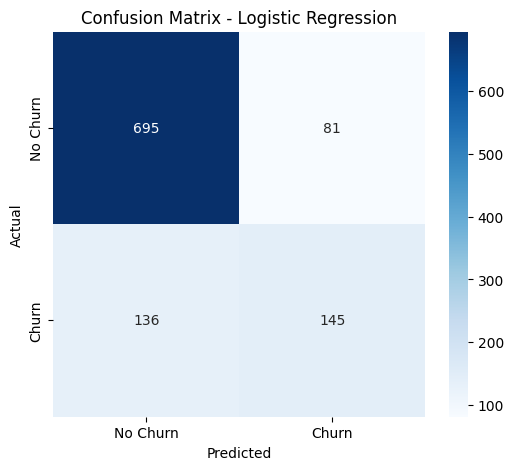

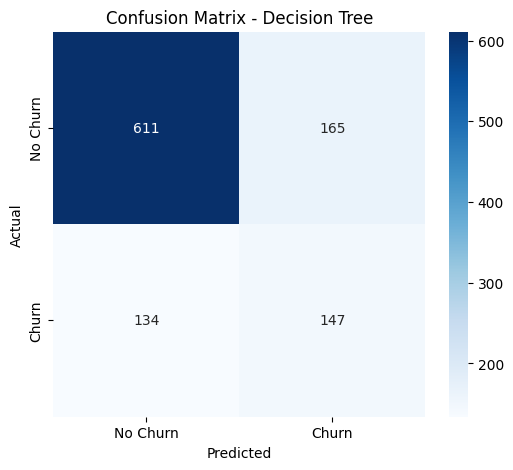

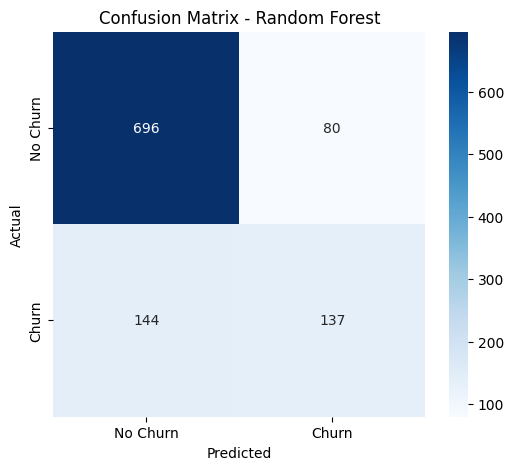

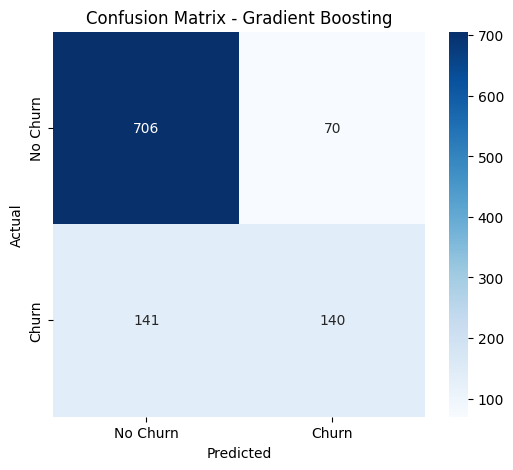

In [ ]:
for name, model in fitted_models.items():
    plot_confusion_matrix(
        name,
        model,
        x_val,
        y_val
    )

#### Depth Track: Classification

#### Cross-Validation

This is basically for the Classification Depth Track.

The project brief specifically asks the Classification Depth Track to use four or more classifiers with cross-validation, plot their ROC curves together, and compare feature importance

##### Stratified 5-Fold Cross-Validation

In [ ]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

**Why stratified?**

Because approximately 26.5% of our customers churn and stratification ensures that each fold maintains a similar churn/non-churn proportion.

##### Define our Cross-Validation Metrics

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [ ]:
cv_results = []

for name, pipeline in model_pipeline.items():

    scores = cross_validate(
        pipeline,
        x_train,
        y_train,
        cv = cv,
        scoring = scoring,
        n_jobs = -1
    )

    cv_results.append({
        'Model': name,
        'Accuracy Mean': scores['test_accuracy'].mean(),
        'Accuracy Std': scores['test_accuracy'].std(),
        'Precision Mean': scores['test_precision'].mean(),
        'Precision Std': scores['test_precision'].std(),
        'Recall Mean': scores['test_recall'].mean(),
        'Recall Std': scores['test_recall'].std(),
        'F1 Mean': scores['test_f1'].mean(),
        'F1 Std': scores['test_f1'].std(),
        'ROC AUC Mean': scores['test_roc_auc'].mean(),
        'ROC AUC Std': scores['test_roc_auc'].std()
    })

cv_comparison = pd.DataFrame(cv_results)

cv_comparison.round(4)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,Logistic Regression,0.8054,0.0095,0.6575,0.0253,0.5597,0.0265,0.6041,0.0187,0.8471,0.0045
1,Decision Tree,0.7371,0.0099,0.5053,0.0183,0.5199,0.0242,0.5119,0.0133,0.6694,0.0085
2,Random Forest,0.7904,0.0081,0.6368,0.0210,0.4908,0.0272,0.5539,0.0202,0.8250,0.0046
3,Gradient Boosting,0.8008,0.0097,0.6590,0.0295,0.5207,0.0104,0.5813,0.0112,0.8442,0.0036


#### Combined ROC Curve

The ROC curve will allow us to compare how the models distinguish churners from non-churners across different probability thresholds.

We'll plot - Logistic Regression, Decision Tree, Random Forest, Gradient Boosting and Stratified Dummy all on one chart, as required for the Classification Depth Track

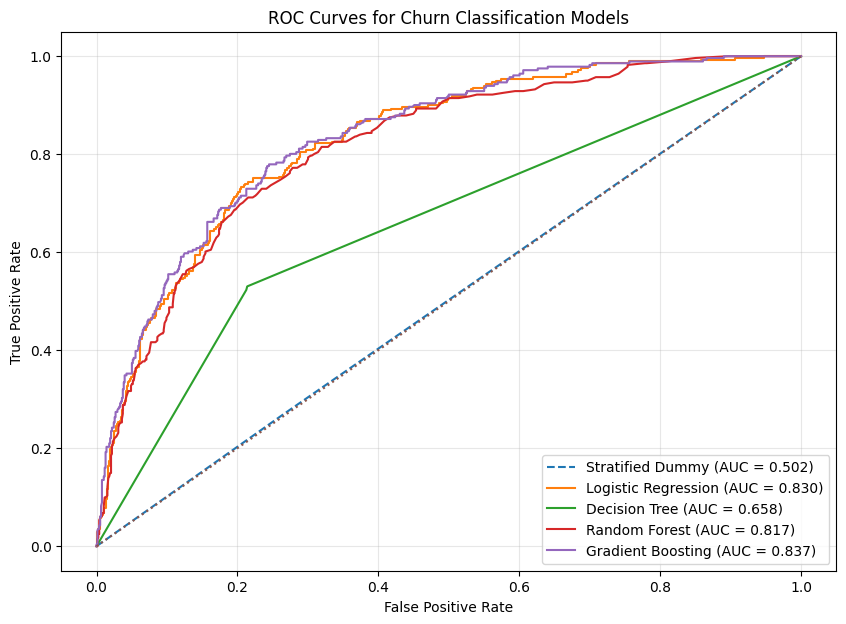

In [ ]:
plt.figure(figsize=(10, 7))

# Dummy baseline
dummy_fpr, dummy_tpr, _ = roc_curve(
    y_val,
    dummy_val_proba
)

plt.plot(
    dummy_fpr,
    dummy_tpr,
    linestyle = '--',
    label = f'Stratified Dummy (AUC = {roc_auc_score(y_val, dummy_val_proba):.3f})'
)

# Classification models
for name, model in fitted_models.items():

    probabilities = model.predict_proba(x_val)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_val,
        probabilities
    )

    model_auc = roc_auc_score(
        y_val,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label = f'{name} (AUC = {model_auc:.3f})'
    )


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle = ':'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Churn Classification Models')
plt.legend()
plt.grid(alpha = 0.3)

plt.show()

**ROC Curve Interpretation**

The ROC curves show the discriminatory performance of the classification models across different probability thresholds. The Stratified Dummy Classifier produces an AUC of 0.502, which is approximately equivalent to random classification and therefore provides an appropriate baseline for comparison.

Among the trained models, Gradient Boosting records the highest validation ROC AUC of 0.837, followed by Logistic Regression at 0.830 and Random Forest at 0.817. Decision Tree records a lower ROC AUC of 0.658, indicating weaker discriminatory ability on the validation data.

The trained models generally maintain ROC curves above the no-skill diagonal, demonstrating that they contain useful information for distinguishing customers who churn from those who do not. However, the validation ROC AUC alone is not sufficient for selecting the final model. Cross-validation results, positive-class F1 performance, feature importance, and the results of imbalance-handling techniques will also be considered before the final model is selected.

#### Investigating Engineered ChargeMonths Feature

This is to confirm if its actually helping the model or just redundant.

In [ ]:
# Create a feature set without ChargeMonths
numerical_features_no_charge_months = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ServiceCount'
]

x_no_charge_months = df_model[
    numerical_features_no_charge_months + categorical_features
].copy()

y = df_model['ChurnBinary'].copy()

# Train/validation/test split should use the SAME indices as before
# so that this is an apples-to-apples comparison.
x_train_no_cm = x_no_charge_months.loc[x_train.index]
y_train_no_cm = y.loc[y_train.index]

classification_preprocessor_no_cm = ColumnTransformer(
    transformers = [
        (
            'num',
            StandardScaler(),
            numerical_features_no_charge_months
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown = 'ignore',
                sparse_output = False
            ),
            categorical_features
        )
    ]
)

comparison_models = {
    'Logistic Regression': LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators = 200,
        random_state = 42,
        n_jobs = -1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state = 42
    )
}

comparison_results = []

for name, model in comparison_models.items():

    pipeline = Pipeline([
        ('preprocessing', classification_preprocessor_no_cm),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipeline,
        x_train_no_cm,
        y_train_no_cm,
        cv=cv,
        scoring = {
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        },
        n_jobs = -1
    )

    comparison_results.append({
        'Model': name,
        'F1 Mean': scores['test_f1'].mean(),
        'ROC AUC Mean': scores['test_roc_auc'].mean()
    })

charge_months_comparison = pd.DataFrame(comparison_results)

display(charge_months_comparison)

,Model,F1 Mean,ROC AUC Mean
0,Logistic Regression,0.606317,0.847206
1,Random Forest,0.544047,0.820333
2,Gradient Boosting,0.588591,0.846124


**Feature Engineering Validation**

The engineered ChargeMonths feature was evaluated by comparing cross-validation performance of selected classification models with and without the feature. The results show only marginal changes in performance. Logistic Regression increased from an F1 score of 0.6041 to 0.6063 and ROC AUC from 0.8471 to 0.8472, while Gradient Boosting increased from 0.5813 to 0.5886 in F1 and from 0.8442 to 0.8461 in ROC AUC. Random Forest performance decreased slightly after removing the feature.

Overall, ChargeMonths does not demonstrate a consistent or material incremental predictive contribution. This is also conceptually reasonable because the feature is derived as TotalCharges / MonthlyCharges and therefore contains information closely related to customer tenure and charging history.

Consequently, ChargeMonths will be excluded from the final modelling feature set to reduce redundancy and maintain a simpler, more interpretable model.

TenureYears was also created as a business-friendly representation of tenure but is not included alongside the original tenure variable because it contains equivalent information. ServiceCount is retained because it provides a distinct representation of the breadth of services subscribed to by each customer.

#### Feature Importance Comparison

Here, we are trying to know which features contribute most to the models' ability to distinguish customers who churn from those who do not. However, because Logistic Regression works differently from the tree-based models, **we will extract Absolute coefficients for Logistic Regression and Feature importance for Decision Tree, Random Forest and Gradient Boosting.**

Also, because our categorical variables were one-hot encoded, a single original variable such as Contract becomes several model features such as Contract_Month-to-month, Contract_One year, Contract_Two year. So we need to retrieve the transformed feature names from the preprocessing pipeline.

The final features excluding the **ChargeMonths** was used after testing the level of relevance to the model.

#### Final Feature Definitions

In [ ]:
numerical_features_final = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ServiceCount'
]

categorical_features_final = [
    col for col in df_model.select_dtypes(include = ['object']).columns
    if col not in ['customerID', 'Churn']
]

#### Final Preprocessing

In [ ]:
classification_preprocessor_final = ColumnTransformer(
    transformers = [
        (
            'num',
            StandardScaler(),
            numerical_features_final
        ),

        (
            'cat',
            OneHotEncoder(
            handle_unknown = 'ignore',
            sparse_output = False
        ),
            categorical_features_final
        )
    ]
)

#### Final Train/Validation/Test Datasets

In [ ]:
x_final = df_model[
    numerical_features_final + categorical_features_final
].copy()

y_final = df_model['ChurnBinary'].copy()

x_train_final = x_final.loc[x_train.index]
x_val_final = x_final.loc[x_val.index]
x_test_final = x_final.loc[x_test.index]

y_train_final = y_final.loc[y_train.index]
y_val_final = y_final.loc[y_val.index]
y_test_final = y_final.loc[y_test.index]

#### Fit the Four Models

In [ ]:
final_models = {
    'Logistic Regression': LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state = 42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators = 200,
        random_state = 42,
        n_jobs = -1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state = 42
    )
}

final_model_pipelines = {}

for name, model in final_models.items():
    pipeline = Pipeline([
        ('preprocessing', classification_preprocessor_final),
        ('classifier', model)
    ])

    pipeline.fit(x_train_final, y_train_final)
    final_model_pipelines[name] = pipeline

print('All four classification pipelines fitted successfully.')

All four classification pipelines fitted successfully.


#### Extract Fitted Models and Feature Names

In [ ]:
logistic_model = final_model_pipelines[
    'Logistic Regression'
].named_steps['classifier']

tree_model = final_model_pipelines[
    'Decision Tree'
].named_steps['classifier']

rf_model = final_model_pipelines[
    'Random Forest'
].named_steps['classifier']

gb_model = final_model_pipelines[
    'Gradient Boosting'
].named_steps['classifier']

feature_names = final_model_pipelines[
    'Logistic Regression'
].named_steps['preprocessing'].get_feature_names_out()

print('Feature count:', len(feature_names))
print('Model extraction successful.')

Feature count: 46
Model extraction successful.


#### Combined Feature-Importance

In [ ]:
importance_comparison = pd.DataFrame({
    'Feature': feature_names,

    # Logistic Regression: retain original coefficient for direction
    'Logistic Coefficient': logistic_model.coef_[0],

    # Absolute coefficient for importance magnitude
    'Logistic Importance': np.abs(logistic_model.coef_[0]),

    # Tree-based importance
    'Decision Tree': tree_model.feature_importances_,
    'Random Forest': rf_model.feature_importances_,
    'Gradient Boosting': gb_model.feature_importances_
})

# Normalize importance measures so they can be compared across models
importance_comparison['Logistic Importance Norm'] = (
    importance_comparison['Logistic Importance'] /
    importance_comparison['Logistic Importance'].max()
)

importance_comparison['Decision Tree Norm'] = (
    importance_comparison['Decision Tree'] /
    importance_comparison['Decision Tree'].max()
)

importance_comparison['Random Forest Norm'] = (
    importance_comparison['Random Forest'] /
    importance_comparison['Random Forest'].max()
)

importance_comparison['Gradient Boosting Norm'] = (
    importance_comparison['Gradient Boosting'] /
    importance_comparison['Gradient Boosting'].max()
)

# Cross-model average importance
importance_comparison['Average Importance'] = (
    importance_comparison[
        [
            'Logistic Importance Norm',
            'Decision Tree Norm',
            'Random Forest Norm',
            'Gradient Boosting Norm'
        ]
    ].mean(axis = 1)
)

importance_comparison = importance_comparison.sort_values(
    'Average Importance',
    ascending = False
)

display(
    importance_comparison[
        [
            'Feature',
            'Logistic Coefficient',
            'Logistic Importance',
            'Decision Tree',
            'Random Forest',
            'Gradient Boosting',
            'Average Importance'
        ]
    ].head(20)
)

,Feature,Logistic Coefficient,Logistic Importance,Decision Tree,Random Forest,Gradient Boosting,Average Importance
37,cat__Contract_Month-to-month,0.629351,0.629351,0.172395,0.049849,0.397430,0.682038
1,num__tenure,-1.281508,1.281508,0.098913,0.133643,0.130629,0.680358
3,num__TotalCharges,0.540752,0.540752,0.188835,0.153800,0.101955,0.669626
2,num__MonthlyCharges,-0.439910,0.439910,0.182372,0.131957,0.082330,0.593546
17,cat__InternetService_Fiber optic,0.556995,0.556995,0.049922,0.023085,0.084628,0.265512
39,cat__Contract_Two year,-0.791765,0.791765,0.000000,0.020055,0.004894,0.190137
16,cat__InternetService_DSL,-0.606904,0.606904,0.000620,0.013567,0.000000,0.141270
44,cat__PaymentMethod_Electronic check,0.196791,0.196791,0.018782,0.030978,0.036305,0.136447
28,cat__TechSupport_No,0.182998,0.182998,0.019244,0.026924,0.049288,0.135945
4,num__ServiceCount,0.186101,0.186101,0.025938,0.033172,0.001116,0.125267


**Feature Importance Findings**

Feature importance was compared across Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting models. For Logistic Regression, the signed coefficient was retained to show direction, while its absolute value was used to measure importance magnitude. Tree-based models used their respective feature importance measures. The importance values were normalized within each model before calculating the cross-model average.

We **Normalized** because the raw Logistic Regression coefficients and tree-based feature importance values are not directly comparable on the same scale.

For example:

Logistic Regression coefficient = 1.28

Random Forest importance = 0.13

We cannot conclude that 1.28 means the Logistic Regression feature is approximately 10 times more important. Hence why we normalized.

Contract type, particularly the **month-to-month category**, emerged as one of the strongest predictors of churn across the models. **Tenure** was also highly influential, with the negative Logistic Regression coefficient indicating that higher tenure is associated with lower predicted churn after controlling for the other variables.

**TotalCharges and MonthlyCharges** also showed substantial predictive importance. However, TotalCharges is strongly related to tenure, so these variables should not be interpreted as completely independent drivers. The Logistic Regression coefficient for MonthlyCharges is negative despite the positive bivariate relationship observed during exploratory analysis. This difference illustrates that multivariable model coefficients represent relationships after controlling for the other predictors in the model.

Other variables with meaningful predictive contributions included Fiber optic internet service, two-year contracts, electronic check payment, technical support, online security, and ServiceCount.

These feature-importance results indicate predictive association rather than causation. Therefore, the variables identified as important should be treated as useful signals for churn prediction rather than evidence that changing any individual variable would necessarily cause churn to increase or decrease.

#### Visualizing Top Features

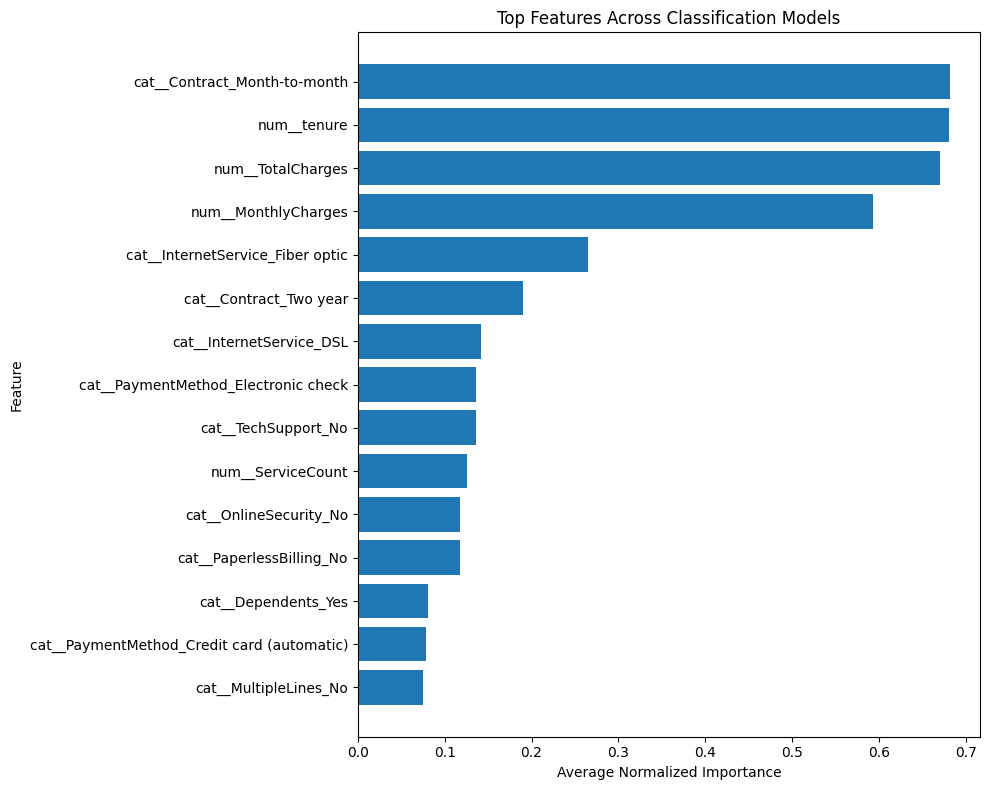

In [ ]:
top_features = importance_comparison.head(15).copy()

top_features = top_features.sort_values(
    'Average Importance',
    ascending = True
)

plt.figure(figsize = (10, 8))

plt.barh(
    top_features['Feature'],
    top_features['Average Importance']
)

plt.xlabel('Average Normalized Importance')
plt.ylabel('Feature')
plt.title('Top Features Across Classification Models')

plt.tight_layout()
plt.show()

#### Examine Logistic Regression Direction

In [ ]:
logistic_direction = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logistic_model.coef_[0]
})

print('Features associated with higher predicted churn:')
display(
    logistic_direction
    .sort_values('Coefficient', ascending=False)
    .head(10)
)

print('Features associated with lower predicted churn:')
display(
    logistic_direction
    .sort_values('Coefficient', ascending=True)
    .head(10)
)

Features associated with higher predicted churn:


,Feature,Coefficient
37,cat__Contract_Month-to-month,0.629351
17,cat__InternetService_Fiber optic,0.556995
3,num__TotalCharges,0.540752
44,cat__PaymentMethod_Electronic check,0.196791
4,num__ServiceCount,0.186101
28,cat__TechSupport_No,0.182998
19,cat__OnlineSecurity_No,0.157083
36,cat__StreamingMovies_Yes,0.116332
33,cat__StreamingTV_Yes,0.107185
22,cat__OnlineBackup_No,0.063018


Features associated with lower predicted churn:


,Feature,Coefficient
1,num__tenure,-1.281508
39,cat__Contract_Two year,-0.791765
16,cat__InternetService_DSL,-0.606904
2,num__MonthlyCharges,-0.439910
40,cat__PaperlessBilling_No,-0.342792
10,cat__Dependents_Yes,-0.253313
20,cat__OnlineSecurity_No internet service,-0.247023
23,cat__OnlineBackup_No internet service,-0.247023
26,cat__DeviceProtection_No internet service,-0.247023
35,cat__StreamingMovies_No internet service,-0.247023


## Part 5: Imbalance Handling

Our **objective** for this section is to answer: Can we improve the model's ability to identify customers who will churn without creating excessive false positives?

The target variable is imbalanced, with churn representing approximately 26.5% of observations and non-churn representing approximately 73.5%. This class distribution can make it more difficult for a classifier to identify the minority churn class effectively.

To address this, three approaches will be evaluated:

- Class weighting, which gives greater importance to the minority class during model training.
- SMOTE (Synthetic Minority Over-sampling Technique), which creates synthetic observations for the minority class within the training data.
- Decision-threshold tuning, which adjusts the probability threshold used to classify a customer as likely to churn.

The approaches are compared using Accuracy, Precision, Recall, F1 Score and ROC AUC. Particular attention is given to positive-class F1 and Recall because the positive class represents customers who churn.

All imbalance-handling techniques will be applied only to training data. Validation data will remain untouched for model and threshold selection, while the test set will remain completely isolated until final evaluation.

#### Establishing the Revised Modelling Dataset

This is because we decided to remove ChargeMonths so it expedient we establish the final feature set first.

In [ ]:
# Final numerical features for modelling
numerical_features_final = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'ServiceCount'
]

# Categorical features remain unchanged
categorical_features_final = categorical_features.copy()

x_final = df_model[
    numerical_features_final + categorical_features_final
].copy()

y_final = df_model['ChurnBinary'].copy()

print('Feature matrix shape:', x_final.shape)
print('Target shape:', y_final.shape)

print('\nClass distribution:')
display(
    y_final.value_counts()
    .rename(index = {0: 'No Churn', 1: 'Churn'})
    .to_frame('Count')
)

print('\nClass proportion:')
display(
    y_final.value_counts(normalize=True)
    .rename(index = {0: 'No Churn', 1: 'Churn'})
    .mul(100)
    .round(2)
    .to_frame('Percentage')
)

Feature matrix shape: (7043, 20)
Target shape: (7043,)

Class distribution:


,Count
ChurnBinary,
No Churn,5174
Churn,1869



Class proportion:


,Percentage
ChurnBinary,
No Churn,73.46
Churn,26.54


#### Recreate the Same Train/Validation/Test Split

In [ ]:
x_train_final = x_final.loc[x_train.index]
x_val_final = x_final.loc[x_val.index]
x_test_final = x_final.loc[x_test.index]

y_train_final = y_final.loc[y_train.index]
y_val_final = y_final.loc[y_val.index]
y_test_final = y_final.loc[y_test.index]

print('Train:', x_train_final.shape)
print('Validation:', x_val_final.shape)
print('Test:', x_test_final.shape)

Train: (4929, 20)
Validation: (1057, 20)
Test: (1057, 20)


#### Recreate our Preprocessing Pipeline

In [ ]:
classification_preprocessor_final = ColumnTransformer(
    transformers = [
        (
            'num',
            StandardScaler(),
            numerical_features_final
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown = 'ignore',
                sparse_output=False
            ),
            categorical_features_final
        )
    ]
)

print('Classification preprocessing pipeline created.')

Classification preprocessing pipeline created.


#### Class-weighted Models

With this model, the algorithm gives greater training importance to the minority class instead of creating additional observations.

We'll test:

- Logistic Regression with class_weight = "balanced"
- Random Forest with class_weight = "balanced"

In [ ]:
weighted_models = {
    'Logistic Regression - Class Weighted': LogisticRegression(
        max_iter = 1000,
        class_weight = 'balanced',
        random_state = 42
    ),

    'Random Forest - Class Weighted': RandomForestClassifier(
        n_estimators = 200,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs = -1
    )
}

weighted_pipelines = {}

for name, model in weighted_models.items():

    weighted_pipelines[name] = Pipeline([
        ('preprocessing', classification_preprocessor_final),
        ('classifier', model)
    ])

#### 5-Fold Cross-Validation

In [ ]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

weighted_cv_results = []

for name, pipeline in weighted_pipelines.items():

    scores = cross_validate(
        pipeline,
        x_train_final,
        y_train_final,
        cv = cv,
        scoring = scoring,
        n_jobs = -1
    )

    weighted_cv_results.append({
        'Model': name,
        'Accuracy Mean': scores['test_accuracy'].mean(),
        'Precision Mean': scores['test_precision'].mean(),
        'Recall Mean': scores['test_recall'].mean(),
        'F1 Mean': scores['test_f1'].mean(),
        'ROC AUC Mean': scores['test_roc_auc'].mean()
    })

weighted_results_df = pd.DataFrame(weighted_cv_results)

display(
    weighted_results_df.round(4)
)

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC AUC Mean
0,Logistic Regression - Class Weighted,0.7525,0.5217,0.8104,0.6346,0.8468
1,Random Forest - Class Weighted,0.7886,0.6380,0.4709,0.5416,0.8210


**Class weighting** produced different effects across the two evaluated models. The class-weighted Logistic Regression achieved a mean recall of 0.8104 and an F1 score of 0.6346, compared with approximately 0.5597 recall and 0.6041 F1 for the corresponding unweighted Logistic Regression model.

The improvement in recall indicates that class weighting helped the Logistic Regression model identify a larger proportion of customers who actually churned. However, this improvement came with lower precision and accuracy, demonstrating the expected trade-off between identifying more positive cases and generating more false positives.

The class-weighted Random Forest achieved a recall of 0.4709 and F1 score of 0.5416. Therefore, in this experiment, class weighting produced a stronger improvement for Logistic Regression than for Random Forest.

ROC AUC remained relatively stable for Logistic Regression (0.8468 compared with approximately 0.8471 for the unweighted model), suggesting that class weighting primarily changed the model's classification behaviour rather than its overall ability to discriminate between churners and non-churners.

#### SMOTE

The important methodological point is that we must not SMOTE the entire dataset before cross-validation. That would allow synthetic information derived from validation observations to influence the training folds.

Instead, we put SMOTE inside the pipeline, so it is performed independently within each training fold.

In [ ]:
smote_pipeline = ImbPipeline([
    ('preprocessing', classification_preprocessor_final),
    ('smote', SMOTE(random_state = 42)),
    ('classifier', LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ))
])

print('SMOTE pipeline created successfully.')

SMOTE pipeline created successfully.


In [ ]:
smote_scores = cross_validate(
    smote_pipeline,
    x_train_final,
    y_train_final,
    cv = cv,
    scoring = scoring,
    n_jobs = -1
)

smote_results_df = pd.DataFrame([{
    'Model': 'Logistic Regression - SMOTE',
    'Accuracy Mean': smote_scores['test_accuracy'].mean(),
    'Precision Mean': smote_scores['test_precision'].mean(),
    'Recall Mean': smote_scores['test_recall'].mean(),
    'F1 Mean': smote_scores['test_f1'].mean(),
    'ROC AUC Mean': smote_scores['test_roc_auc'].mean()
}])

display(smote_results_df.round(4))

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC AUC Mean
0,Logistic Regression - SMOTE,0.7567,0.5278,0.792,0.6333,0.8459


#### Create Comparison Table

In [ ]:
# Standard Logistic Regression results from Part 4
standard_logistic_results = pd.DataFrame([{
    'Model': 'Logistic Regression - Standard',
    'Accuracy Mean': 0.8054,
    'Precision Mean': 0.6575,
    'Recall Mean': 0.5597,
    'F1 Mean': 0.6041,
    'ROC AUC Mean': 0.8471
}])

# Combine imbalance-handling results
logistic_imbalance_comparison = pd.concat(
    [
        standard_logistic_results,
        weighted_results_df[
            weighted_results_df['Model']
            == 'Logistic Regression - Class Weighted'
        ],
        smote_results_df
    ],
    ignore_index=True
)

display(
    logistic_imbalance_comparison.round(4)
)

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC AUC Mean
0,Logistic Regression - Standard,0.8054,0.6575,0.5597,0.6041,0.8471
1,Logistic Regression - Class Weighted,0.7525,0.5217,0.8104,0.6346,0.8468
2,Logistic Regression - SMOTE,0.7567,0.5278,0.7920,0.6333,0.8459


**Comparison of Imbalance-Handling Approaches**

The **standard Logistic Regression model achieved the highest accuracy and precision**, but its recall for the positive class was considerably lower. This indicates that the standard model is more conservative in identifying customers who are likely to churn.

Both **class weighting and SMOTE substantially increased positive-class recall and F1 score.** Class-weighted Logistic Regression achieved a recall of 0.8104 and F1 score of 0.6346, while SMOTE achieved a recall of 0.7920 and F1 score of 0.6333.

The two imbalance-handling approaches produced very similar ROC AUC values, indicating that neither method materially changed the model's overall ranking ability. Instead, their primary effect was to change the balance between positive and negative predictions.

Given the stated business assumption that failing to identify a genuine churner is more costly than contacting a customer who ultimately does not churn, the higher recall achieved through imbalance handling is particularly relevant. However, the resulting reduction in precision demonstrates that additional false positives would also be generated.

#### Threshold Tuning

Here, we answer "How should the model's probability threshold reflect the business cost of missing a churner?"

**Our Business assumption**

For this analysis, we **assume that missing a genuine churner carries a higher business cost than contacting a customer who ultimately does not churn.** This is a modelling assumption not a claim about the actual financial cost structure of the organization.

Therefore, we'll investigate whether lowering the threshold can improve churn detection while maintaining a reasonable F1 score.

#### Fit the standard Logistic Regression on Training Data

We used the standard Logistic Regression pipeline because threshold tuning is intended to demonstrate how the classification decision can be adjusted independently of the underlying probability ranking.

In [ ]:
# Standard Logistic Regression pipeline

threshold_model = Pipeline([
    ('preprocessing', classification_preprocessor_final),
    ('classifier', LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ))
])

threshold_model.fit(
    x_train_final,
    y_train_final
)

# Validation-set probabilities
val_probabilities = threshold_model.predict_proba(
    x_val_final
)[:, 1]

print('Validation probabilities generated successfully.')

Validation probabilities generated successfully.


#### Evaluate Different Probability Thresholds

In [ ]:
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    val_predictions = (
        val_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(
            y_val_final,
            val_predictions
        ),
        'Precision': precision_score(
            y_val_final,
            val_predictions,
            zero_division = 0
        ),
        'Recall': recall_score(
            y_val_final,
            val_predictions,
            zero_division = 0
        ),
        'F1': f1_score(
            y_val_final,
            val_predictions,
            zero_division = 0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(
    threshold_results_df.round(4)
)

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.7020,0.4659,0.8256,0.5956
1,0.25,0.7342,0.5000,0.7829,0.6103
2,0.30,0.7673,0.5452,0.7509,0.6317
3,0.35,0.7805,0.5706,0.7046,0.6306
4,0.40,0.7833,0.5855,0.6335,0.6085
5,0.45,0.7843,0.6008,0.5623,0.5809
6,0.50,0.7947,0.6416,0.5160,0.5720
7,0.55,0.7994,0.6788,0.4662,0.5527
8,0.60,0.7881,0.6887,0.3701,0.4815
9,0.65,0.7852,0.7288,0.3060,0.4311


#### Ploting the Precision–Recall Curve

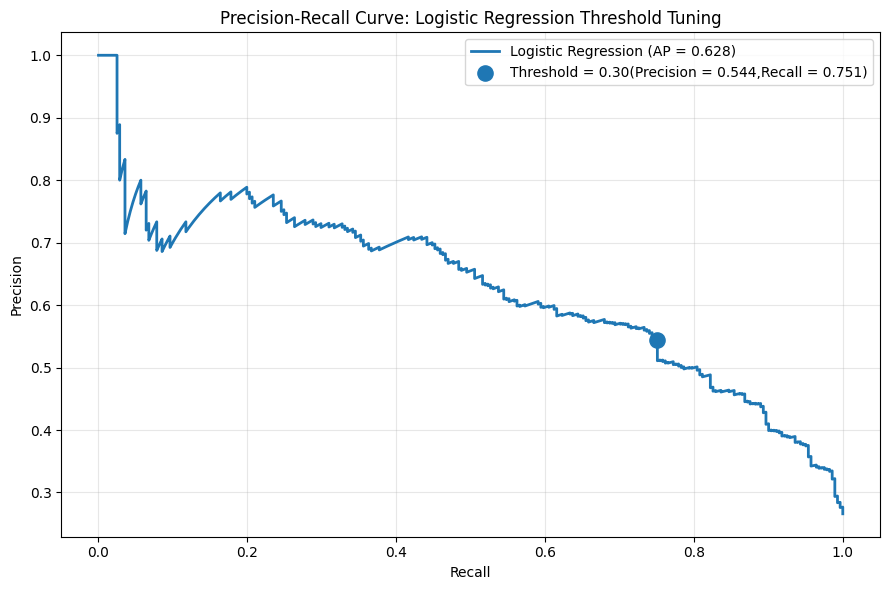

Average Precision: 0.6277
Selected Threshold: 0.30
Precision at Selected Threshold: 0.5438
Recall at Selected Threshold: 0.7509


In [ ]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_val_final,
    val_probabilities
)

average_precision = average_precision_score(
    y_val_final,
    val_probabilities
)

selected_threshold = 0.30

threshold_index = np.argmin(
    np.abs(pr_thresholds - selected_threshold)
)

selected_precision = precision_curve[threshold_index]
selected_recall = recall_curve[threshold_index]

plt.figure(figsize=(9, 6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label = f'Logistic Regression (AP = {average_precision:.3f})'
)

plt.scatter(
    selected_recall,
    selected_precision,
    s = 120,
    zorder = 5,
    label = (
        f'Threshold = {selected_threshold:.2f}'
        f'(Precision = {selected_precision:.3f},'
        f'Recall = {selected_recall:.3f})'
    )
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Logistic Regression Threshold Tuning')
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

print(f'Average Precision: {average_precision:.4f}')
print(f'Selected Threshold: {selected_threshold:.2f}')
print(f'Precision at Selected Threshold: {selected_precision:.4f}')
print(f'Recall at Selected Threshold: {selected_recall:.4f}')

#### Precision-Recall Curve and Threshold Selection

Because the churn class is the minority class, the Precision-Recall relationship provides a useful basis for selecting an operating threshold. Unlike ROC AUC, which evaluates ranking performance across all possible thresholds, the Precision-Recall curve focuses directly on the trade-off between identifying churners and generating false-positive churn alerts.

The Precision-Recall curve was generated using the validation-set churn probabilities from the Standard Logistic Regression model.

A business cost assumption was established before selecting the threshold: **a false negative, where a genuine churner is not identified, is assumed to be more costly than a false positive, where a customer is targeted for retention but ultimately does not churn.**

Under this assumption, a lower classification threshold is desirable because it increases Recall and therefore reduces the number of missed churners. However, setting the threshold too low also reduces Precision and increases the number of customers who would receive potentially unnecessary retention interventions.

The validation threshold analysis showed:

- At threshold 0.20, Recall increased to 0.8256, but Precision declined to 0.4659 and F1 Score declined to 0.5956.
- At threshold 0.30, Recall was 0.7509, Precision was 0.5452, and F1 Score reached its highest value of 0.6317.
- At the default threshold of 0.50, Precision increased to 0.6416, but Recall declined substantially to 0.5160.

Based on this Precision-Recall trade-off, a threshold of **0.30** was selected. It provides substantially higher churn detection than the default threshold while maintaining a better balance between Precision and Recall than the more aggressive 0.20 threshold.

The threshold was selected using the validation dataset only. The test dataset remained untouched until final model evaluation.

#### Evaluate all Imbalance Approaches on the Validation Set

In [ ]:
# ---------------------------------------------------------
# 1. Fit Class-Weighted Logistic Regression
# ---------------------------------------------------------
weighted_logistic_pipeline = Pipeline([
    ('preprocessing', classification_preprocessor_final),
    ('classifier', LogisticRegression(
        max_iter = 1000,
        class_weight = 'balanced',
        random_state = 42
    ))
])

weighted_logistic_pipeline.fit(x_train_final, y_train_final)

weighted_val_prob = weighted_logistic_pipeline.predict_proba(
    x_val_final
)[:, 1]

weighted_val_pred = (weighted_val_prob >= 0.50).astype(int)


# ---------------------------------------------------------
# 2. Fit SMOTE Logistic Regression
# ---------------------------------------------------------
smote_logistic_pipeline = ImbPipeline([
    ('preprocessing', classification_preprocessor_final),
    ('smote', SMOTE(random_state = 42)),
    ('classifier', LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ))
])

smote_logistic_pipeline.fit(x_train_final, y_train_final)

smote_val_prob = smote_logistic_pipeline.predict_proba(
    x_val_final
)[:, 1]

smote_val_pred = (smote_val_prob >= 0.50).astype(int)


# ---------------------------------------------------------
# 3. Evaluate validation performance
# ---------------------------------------------------------
validation_imbalance_results = pd.DataFrame([
    {
        'Model': 'Standard Logistic - Threshold 0.30',
        'Accuracy': accuracy_score(
            y_val_final,
            (val_probabilities >= 0.30).astype(int)
        ),
        'Precision': precision_score(
            y_val_final,
            (val_probabilities >= 0.30).astype(int)
        ),
        'Recall': recall_score(
            y_val_final,
            (val_probabilities >= 0.30).astype(int)
        ),
        'F1': f1_score(
            y_val_final,
            (val_probabilities >= 0.30).astype(int)
        ),
        'ROC AUC': roc_auc_score(
            y_val_final,
            val_probabilities
        )
    },
    {
        'Model': 'Class-Weighted Logistic',
        'Accuracy': accuracy_score(
            y_val_final,
            weighted_val_pred
        ),
        'Precision': precision_score(
            y_val_final,
            weighted_val_pred
        ),
        'Recall': recall_score(
            y_val_final,
            weighted_val_pred
        ),
        'F1': f1_score(
            y_val_final,
            weighted_val_pred
        ),
        'ROC AUC': roc_auc_score(
            y_val_final,
            weighted_val_prob
        )
    },
    {
        'Model': 'SMOTE Logistic',
        'Accuracy': accuracy_score(
            y_val_final,
            smote_val_pred
        ),
        'Precision': precision_score(
            y_val_final,
            smote_val_pred
        ),
        'Recall': recall_score(
            y_val_final,
            smote_val_pred
        ),
        'F1': f1_score(
            y_val_final,
            smote_val_pred
        ),
        'ROC AUC': roc_auc_score(
            y_val_final,
            smote_val_prob
        )
    }
])

validation_imbalance_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Standard Logistic - Threshold 0.30,0.7673,0.5452,0.7509,0.6317,0.8297
1,Class-Weighted Logistic,0.7427,0.5106,0.7687,0.6136,0.8292
2,SMOTE Logistic,0.7531,0.5243,0.7687,0.6234,0.8302


#### Comparing the Three Approaches Visually

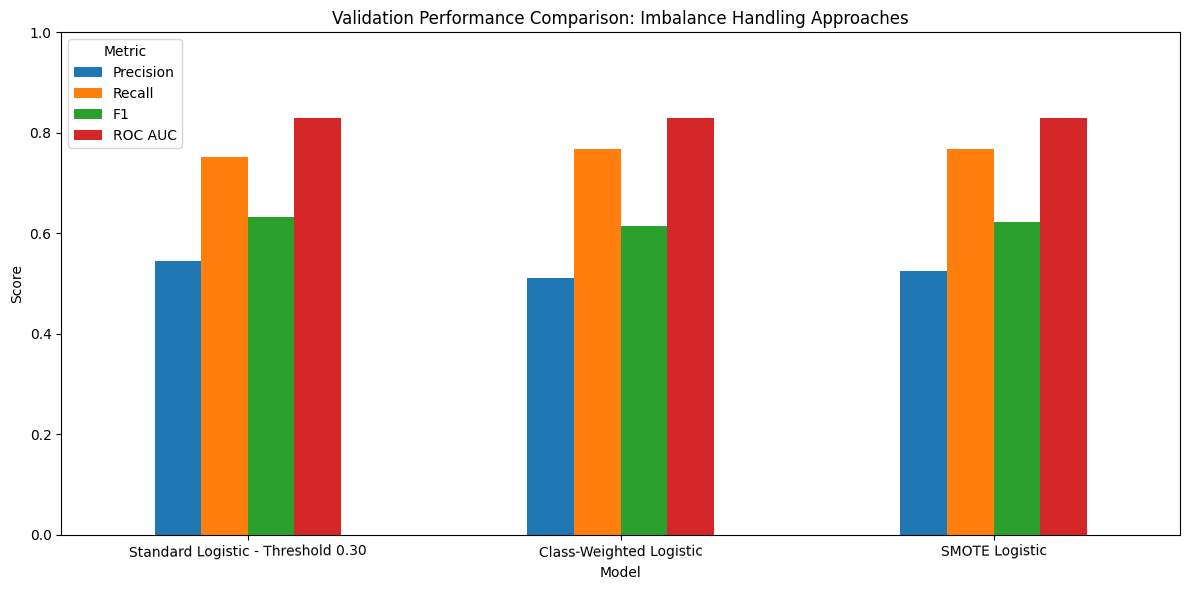

In [ ]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC AUC']

validation_imbalance_results.set_index('Model')[metrics_to_plot].plot(
    kind = 'bar',
    figsize = (12, 6)
)

plt.title('Validation Performance Comparison: Imbalance Handling Approaches')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation = 0.5)
plt.legend(title = 'Metric')
plt.tight_layout()
plt.show()

#### Validation Comparison of Imbalance-Handling Approaches

To ensure a fair comparison, the imbalance-handling approaches were evaluated on the same validation dataset. Three Logistic Regression configurations were compared:

1. Standard Logistic Regression with the tuned threshold of 0.30.
2. Class-Weighted Logistic Regression using class_weight = 'balanced'.
3. Logistic Regression trained using SMOTE to oversample the minority class.

**The comparison focuses particularly on Recall and F1 Score** because the positive class represents customers who churn. Recall measures the proportion of actual churners identified by the model, while F1 balances Recall and Precision.

The threshold-tuned Standard Logistic Regression demonstrates how changing the classification threshold can increase the model's sensitivity to churn without changing the underlying probability model. Class weighting addresses the imbalance by assigning greater importance to the minority class during model training, while SMOTE creates synthetic minority-class observations within the training process.

The validation results provide an apples-to-apples comparison because all three approaches are evaluated on the same untouched validation dataset. The test dataset is not used for this selection process.

#### Check Confusion Matrices

We created this to explain the business impact of the threshold decision.

In [ ]:
validation_predictions = {
    'Standard Logistic - Threshold 0.30':
        (val_probabilities >= 0.30).astype(int),

    'Class-Weighted Logistic':
        weighted_val_pred,

    'SMOTE Logistic':
        smote_val_pred
}

for model_name, predictions in validation_predictions.items():

    print(f"\n{model_name}")
    print(confusion_matrix(y_val_final, predictions))


Standard Logistic - Threshold 0.30
[[600 176]
 [ 70 211]]

Class-Weighted Logistic
[[569 207]
 [ 65 216]]

SMOTE Logistic
[[580 196]
 [ 65 216]]


The key business number for this project is **FN — false negatives**, because these are customers who actually churned but were not identified as likely churners.

#### Final Comparison of Imbalance-Handling Approaches

The three imbalance-handling approaches were evaluated on the same validation dataset to provide a consistent comparison.

**Standard Logistic Regression with a classification threshold of 0.30** achieved an Accuracy of 0.7673, Precision of 0.5452, Recall of 0.7509, F1 Score of 0.6317, and ROC AUC of 0.8297.

**Class-Weighted Logistic Regression** produced a higher Recall of 0.7687 but a lower Precision of 0.5106 and F1 Score of 0.6136. This indicates that class weighting identified slightly more churners but generated more false-positive predictions.

**SMOTE Logistic Regression** also achieved a Recall of 0.7687 and produced a slightly higher ROC AUC of 0.8302. However, its F1 Score of 0.6234 remained below the 0.6317 achieved by the threshold-tuned Standard Logistic Regression.

Considering the stated business assumption that missing a genuine churner is more costly than contacting a customer who does not ultimately churn, Recall is an important consideration. However, the F1 Score provides a useful balance between identifying churners and limiting false-positive interventions.

**Based on the validation results, Standard Logistic Regression with a threshold of 0.30 was selected as the current final candidate because it achieved the highest validation F1 Score while maintaining a Recall of 0.7509. The ROC AUC values were also broadly similar across the three approaches.**

The test dataset remains untouched and will be used only for final evaluation of the selected model.

#### Applying Our Final Selected Model

We made the model-selection decision without touching the test set. The next cell evaluate the selected model against the completely unseen test data.

In [ ]:
# Generate predictions on the untouched test set
test_probabilities = threshold_model.predict_proba(
    x_test_final
)[:, 1]

# Apply selected threshold
test_predictions = (test_probabilities >= 0.30).astype(int)

# Calculate final test metrics
final_test_results = pd.DataFrame([{
    'Model': 'Logistic Regression - Threshold 0.30',
    'Accuracy': accuracy_score(y_test_final, test_predictions),
    'Precision': precision_score(y_test_final, test_predictions),
    'Recall': recall_score(y_test_final, test_predictions),
    'F1': f1_score(y_test_final, test_predictions),
    'ROC AUC': roc_auc_score(y_test_final, test_probabilities)
}])

final_test_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression - Threshold 0.30,0.7559,0.527,0.7679,0.625,0.8503


#### Test Confusion Matrix

Confusion Matrix:
[[584 193]
 [ 65 215]]


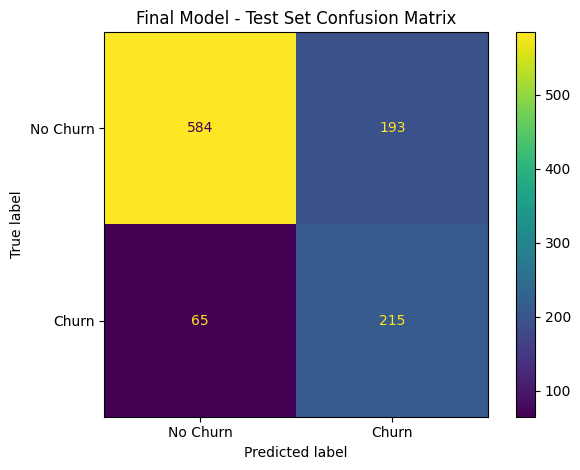

In [ ]:
final_test_cm = confusion_matrix(
    y_test_final,
    test_predictions
)

print('Confusion Matrix:')
print(final_test_cm)

ConfusionMatrixDisplay(
    confusion_matrix = final_test_cm,
    display_labels = ['No Churn', 'Churn']
).plot()

plt.title('Final Model - Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

#### Final Test-Set Evaluation

After selecting the classification threshold using the validation dataset, the selected Logistic Regression model was evaluated once on the previously untouched test dataset.

Using a classification threshold of **0.30**, the model achieved:

- Accuracy: 0.7559
- Precision: 0.5270
- Recall: 0.7679
- F1 Score: 0.6250
- ROC AUC: 0.8503

The confusion matrix contained 584 true negatives, 193 false positives, 65 false negatives, and 215 true positives.

**The model correctly identified 215 of the 280 customers who churned in the test set**, corresponding to a Recall of 76.79%. It missed 65 actual churners.

The lower classification threshold increases the model's sensitivity to the positive class. This is consistent with the modelling assumption that failing to identify a genuine churner is more costly than contacting a customer who ultimately does not churn.

**The final ROC AUC of 0.8503 is above the project's minimum requirement of 0.75.** The positive-class F1 Score of 0.6250 also substantially exceeds the Stratified Dummy Classifier baseline F1 Score of 0.2679.

Importantly, the test dataset was not used during model selection or threshold tuning. It was reserved for this final evaluation, providing an unbiased estimate of performance on unseen data.

#### Part 5 Summary Table

In [ ]:
part5_summary = pd.DataFrame([
    {
        'Model': 'Stratified Dummy',
        'Dataset': 'Validation',
        'Threshold': 0.50,
        'Accuracy': 0.6121,
        'Precision': 0.2688,
        'Recall': 0.2669,
        'F1': 0.2679,
        'ROC AUC': 0.5020
    },
    {
        'Model': 'Standard Logistic',
        'Dataset': 'Validation',
        'Threshold': 0.50,
        'Accuracy': 0.7947,
        'Precision': 0.6416,
        'Recall': 0.5160,
        'F1': 0.5720,
        'ROC AUC': 0.8297
    },
    {
        'Model': 'Standard Logistic',
        'Dataset': 'Validation',
        'Threshold': 0.30,
        'Accuracy': 0.7673,
        'Precision': 0.5452,
        'Recall': 0.7509,
        'F1': 0.6317,
        'ROC AUC': 0.8297
    },
    {
        'Model': 'Class-Weighted Logistic',
        'Dataset': 'Validation',
        'Threshold': 0.50,
        'Accuracy': 0.7427,
        'Precision': 0.5106,
        'Recall': 0.7687,
        'F1': 0.6136,
        'ROC AUC': 0.8292
    },
    {
        'Model': 'SMOTE Logistic',
        'Dataset': 'Validation',
        'Threshold': 0.50,
        'Accuracy': 0.7531,
        'Precision': 0.5243,
        'Recall': 0.7687,
        'F1': 0.6234,
        'ROC AUC': 0.8302
    },
    {
        'Model': 'Final Logistic',
        'Dataset': 'Test',
        'Threshold': 0.30,
        'Accuracy': 0.7559,
        'Precision': 0.5270,
        'Recall': 0.7679,
        'F1': 0.6250,
        'ROC AUC': 0.8503
    }
])

part5_summary.round(4)

,Model,Dataset,Threshold,Accuracy,Precision,Recall,F1,ROC AUC
0,Stratified Dummy,Validation,0.5,0.6121,0.2688,0.2669,0.2679,0.5020
1,Standard Logistic,Validation,0.5,0.7947,0.6416,0.5160,0.5720,0.8297
2,Standard Logistic,Validation,0.3,0.7673,0.5452,0.7509,0.6317,0.8297
3,Class-Weighted Logistic,Validation,0.5,0.7427,0.5106,0.7687,0.6136,0.8292
4,SMOTE Logistic,Validation,0.5,0.7531,0.5243,0.7687,0.6234,0.8302
5,Final Logistic,Test,0.3,0.7559,0.5270,0.7679,0.6250,0.8503


#### Part 5 Conclusion

The churn target was moderately imbalanced, with churned customers representing approximately 26.5% of the dataset. Three approaches were investigated to address the imbalance: class weighting, SMOTE, and classification-threshold tuning.

Class weighting increased the model's ability to identify churners, achieving a validation Recall of 0.7687, while SMOTE achieved a similar Recall of 0.7687. However, both approaches produced lower validation F1 Scores than the threshold-tuned Standard Logistic Regression.

**The Standard Logistic Regression model with a threshold of 0.30 achieved the highest validation F1 Score of 0.6317 while maintaining a Recall of 0.7509. This approach was therefore selected for final evaluation.**

**On the untouched test dataset, the selected model achieved an F1 Score of 0.6250 and ROC AUC of 0.8503. The model identified 76.79% of actual churners, with 65 false negatives out of 280 actual churners.**

The final model therefore exceeds the Stratified Dummy Classifier baseline and the project's minimum ROC AUC requirement of 0.75. The results demonstrate that threshold tuning provided a practical way to increase sensitivity to churn while maintaining a reasonable balance between Precision and Recall.

The selected threshold and model should be interpreted in the context of the stated modelling assumption regarding the relative cost of false negatives and false positives.

## Part 6: The Tie-In

The clustering analysis in Part 3 identified three customer segments without using the Churn target. This separation was intentional so that the customer segments would be based on customer characteristics and service behaviour rather than on the outcome we later aim to predict.

In this section, the Churn outcome is reintroduced to determine whether the resulting customer segments exhibit different churn behaviour.

For each cluster, the positive-class rate is calculated as the proportion of customers whose Churn value is **'Yes'**. The resulting churn rates are compared across the three clusters to determine whether the unsupervised customer segments provide meaningful insight into churn behaviour.

A meaningful difference in churn rates across clusters would suggest that the customer characteristics captured by the clustering process are associated with different levels of observed churn. However, this analysis is descriptive and does not imply that cluster membership itself causes churn.

#### Calculate Churn Rate by Cluster

In [ ]:
cluster_churn = (
    df_model
    .groupby('Cluster')
    .agg(
        Customers = ('ChurnBinary', 'size'),
        Churned_Customers = ('ChurnBinary', 'sum'),
        Churn_Rate = ('ChurnBinary', 'mean')
    )
    .reset_index()
)

cluster_churn['Churn_Rate'] = cluster_churn['Churn_Rate'] * 100

cluster_churn.round(2)

,Cluster,Customers,Churned_Customers,Churn_Rate
0,0,2394,362,15.12
1,1,1526,113,7.40
2,2,3123,1394,44.64


#### Add the Cluster Names

In [ ]:
cluster_names = {
    0: 'Established, High-Value Customers',
    1: 'Basic / Non-Internet Customers',
    2: 'Newer, Flexible-Service Customers'
}

cluster_churn['Cluster_Name'] = cluster_churn['Cluster'].map(
    cluster_names
)

cluster_churn = cluster_churn[
    [
        'Cluster',
        'Cluster_Name',
        'Customers',
        'Churned_Customers',
        'Churn_Rate'
    ]
]

cluster_churn.round(2)

,Cluster,Cluster_Name,Customers,Churned_Customers,Churn_Rate
0,0,"Established, High-Value Customers",2394,362,15.12
1,1,Basic / Non-Internet Customers,1526,113,7.40
2,2,"Newer, Flexible-Service Customers",3123,1394,44.64


#### Plot Churn Rate by Cluster

This visualization is important because part 6 is essentially asking whether the clusters differentiate churn behaviour.

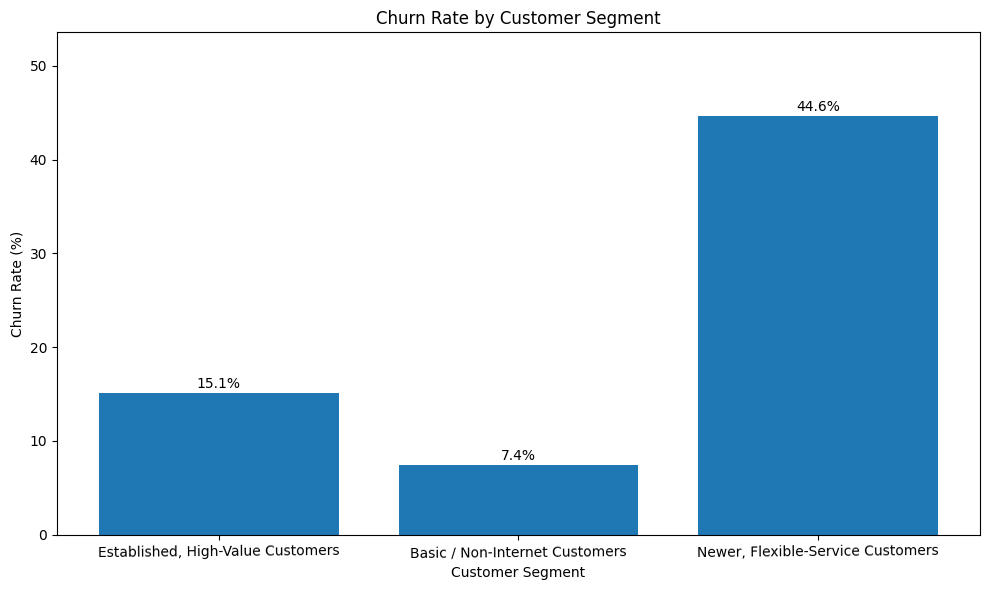

In [ ]:
plt.figure(figsize = (10, 6))

bars = plt.bar(
    cluster_churn['Cluster_Name'],
    cluster_churn['Churn_Rate']
)

plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Segment')
plt.title('Churn Rate by Customer Segment')
plt.xticks(rotation = 0.5)
plt.ylim(0, max(cluster_churn['Churn_Rate']) * 1.2)

for bar, value in zip(bars, cluster_churn['Churn_Rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{value:.1f}%',
        ha = 'center'
    )

plt.tight_layout()
plt.show()

#### Calculate the Overall Churn Rate

In [ ]:
overall_churn_rate = df_model['ChurnBinary'].mean() * 100

print(f'Overall churn rate: {overall_churn_rate:.2f}%')

Overall churn rate: 26.54%


#### Calculate Difference from Overall Churn

In [ ]:
cluster_churn['Difference_vs_Overall_pp'] = (
    cluster_churn['Churn_Rate'] - overall_churn_rate
)

cluster_churn.round(2)

,Cluster,Cluster_Name,Customers,Churned_Customers,Churn_Rate,Difference_vs_Overall_pp
0,0,"Established, High-Value Customers",2394,362,15.12,-11.42
1,1,Basic / Non-Internet Customers,1526,113,7.40,-19.13
2,2,"Newer, Flexible-Service Customers",3123,1394,44.64,18.10


#### Cluster Churn Analysis

The three customer segments exhibit substantially different observed churn rates.

The **Newer, Flexible-Service Customers** segment has the highest churn rate at **44.64%**, which is 18.10 percentage points above the overall dataset churn rate of approximately 26.54%. This segment contains 3,123 customers, of whom 1,394 churned.

The **Established, High-Value Customers** segment has an observed churn rate of **15.12%**, which is 11.42 percentage points below the overall churn rate. This segment contains 2,394 customers, with 362 recorded churners.

The **Basic / Non-Internet Customers** segment has the lowest observed churn rate at **7.40%**, which is 19.13 percentage points below the overall rate. The segment contains 1,526 customers, with 113 recorded churners.

These differences indicate that the customer characteristics identified through the unsupervised clustering process are associated with materially different observed churn behaviour. In particular, the Newer, Flexible-Service Customers segment represents a customer group with a substantially higher observed churn rate than the other two segments.

However, these results should be interpreted as descriptive associations rather than causal relationships. The clustering algorithm was performed without using the Churn outcome, so the observed differences provide a useful link between customer segmentation and churn behaviour but do not establish that cluster membership itself causes churn.

The result also demonstrates the complementary value of the two analytical approaches used in this project:

- **Clustering** identifies distinct customer segments based on customer characteristics and service behaviour.
- **Classification** estimates the likelihood that an individual customer will churn.
- **The Tie-In** shows that the independently identified customer segments exhibit different observed churn rates.

Therefore, the clustering analysis provides an additional business segmentation perspective that can complement the individual-level churn classification model.

#### Part 6 Conclusion

The clustering and classification analyses provide complementary views of customer churn.

The clustering analysis identified three customer segments without using the Churn outcome. When the Churn variable was subsequently reintroduced, the segments showed substantially different observed churn rates: 15.12% for Established, High-Value Customers, 7.40% for Basic / Non-Internet Customers, and 44.64% for Newer, Flexible-Service Customers.

The 44.64% churn rate observed among Newer, Flexible-Service Customers is considerably higher than the overall churn rate of approximately 26.54%, while the other two segments have churn rates below the overall rate.

This demonstrates that the unsupervised segmentation captures customer characteristics that are associated with different churn behaviours. However, the clustering results are descriptive and should not be interpreted as evidence that cluster membership causes churn.

The classification model remains the appropriate tool for estimating individual customer churn probability, while the clusters provide a complementary customer-segmentation perspective that can support differentiated business analysis and retention planning.

## Part 7: Conclusion and Recommendations

### Overall Conclusion

This project used both unsupervised and supervised machine-learning techniques to investigate customer churn in the Telco Customer Churn dataset.

The analysis began with exploratory data analysis and data cleaning, followed by feature engineering and preprocessing. Three additional features were created: TenureYears, ServiceCount, and ChargeMonths. After evaluating their contribution, ChargeMonths was excluded from the final predictive feature set because it provided no material and consistent improvement over the original variables. TenureYears was also excluded from the final model because it duplicates the information contained in tenure. ServiceCount was retained because it provides an interpretable measure of the number of subscribed services.

For **customer segmentation**, K-Means clustering was evaluated from K=2 to K=10. Both the elbow curve and silhouette analysis supported K=3. The resulting clusters represented three distinct customer segments:

- Established, High-Value Customers
- Basic / Non-Internet Customers and
- Newer, Flexible-Service Customers.

The classification analysis compared a Stratified Dummy Classifier with Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. The classification models were evaluated using Accuracy, Precision, Recall, F1 Score and ROC AUC, with stratified cross-validation used as part of the deeper Classification Track analysis.

**Because the target variable was imbalanced, class weighting, SMOTE and decision-threshold tuning were investigated**. A threshold of 0.30 was selected for the Standard Logistic Regression model using the validation dataset. This threshold produced a validation F1 Score of 0.6317 and Recall of 0.7509.

On the previously untouched test dataset, the final Logistic Regression model using the 0.30 threshold achieved:

- Accuracy: 0.7559
- Precision: 0.5270
- Recall: 0.7679
- F1 Score: 0.6250
- ROC AUC: 0.8503

The final model therefore exceeded the Stratified Dummy Classifier baseline and the project's minimum ROC AUC requirement of 0.75.

### Recommended Model for Deployment

The Logistic Regression model with a classification threshold of 0.30 would be the model taken forward as the deployment candidate for this project.

The selection was based on the validation results rather than the final test results. The 0.30 threshold produced the highest validation F1 Score among the imbalance-handling approaches evaluated while substantially increasing Recall compared with the default 0.50 threshold.

The choice also reflects the stated modelling assumption that missing a genuine churner is more costly than contacting a customer who ultimately does not churn. Under that assumption, identifying a larger proportion of potential churners is important.

The final test evaluation confirmed that the selected approach generalised reasonably well to unseen data, achieving a Recall of 76.79%, F1 Score of 0.6250 and ROC AUC of 0.8503.

In a real production environment, the threshold should not be considered permanently fixed. It should be recalibrated using actual retention-intervention costs, customer value, available intervention capacity and observed outcomes.

### What We Would Do With Another Month

With an additional month, the next stage would focus on improving both model reliability and business usability.

First, we would perform more extensive hyperparameter tuning for the classification models, particularly Logistic Regression, Random Forest and Gradient Boosting. This would determine whether additional performance can be achieved without compromising interpretability or generalisation.

Second, we would investigate probability calibration. Since the model produces churn probabilities that could potentially be used to prioritise retention activities, calibration would help determine whether predicted probabilities correspond appropriately to observed churn frequencies.

Third, we would investigate the business cost of false positives and false negatives using real retention-campaign data. This would allow the classification threshold to be selected using an explicit cost-based framework rather than the modelling assumption used in this project.

Fourth, we would investigate model stability across customer subgroups and different time periods. This would help determine whether model performance remains consistent as customer behaviour changes.

Finally, we would develop a practical churn-monitoring dashboard showing customer churn probability, customer segment, key contributing factors and retention-priority groups. This would translate the analytical output into a business-facing decision-support tool.

### What the Clusters Revealed That Classification Did Not

The classification model and clustering analysis answer different questions.

The classification model focuses on predicting whether an individual customer is likely to churn. Its feature-importance analysis identified variables such as contract type, tenure, TotalCharges, MonthlyCharges and internet-service characteristics as important predictive signals.

The clustering analysis provided a complementary view by showing how these characteristics combine into broader customer segments.

Most importantly, the three independently created clusters exhibited substantially different observed churn rates:

- Established, High-Value Customers: 15.12%
- Basic / Non-Internet Customers: 7.40%
- Newer, Flexible-Service Customers: 44.64%

The Newer, Flexible-Service Customers segment therefore had an observed churn rate substantially above the overall dataset churn rate of approximately 26.54%.

This segmentation insight is different from an individual-level churn prediction. A classifier can estimate which individual customers are more likely to churn, while clustering can help the business understand the broader types of customers that exist within its customer base.

The cluster analysis therefore adds a customer-segmentation perspective that can complement the individual predictions generated by the classification model.

### Hardest Decision Made

One of the most important decisions in the project was determining how to handle the imbalance in the Churn target and selecting the final operating threshold.

The default 0.50 threshold produced higher Precision but relatively lower Recall for the churn class. Class weighting and SMOTE increased Recall, but the validation results showed that the 0.30 threshold applied to the standard Logistic Regression model produced the strongest balance according to F1 Score.

Selecting the threshold therefore required balancing statistical performance with a stated business assumption about the relative cost of missing genuine churners versus contacting customers who ultimately do not churn.

Another important decision was excluding ChargeMonths from the final predictive feature set. Although the feature was logically derived from TotalCharges and MonthlyCharges, model validation showed no material and consistent improvement from retaining it. Removing it reduced redundancy and produced a simpler final feature set.

### Final Takeaway

The project demonstrates that customer churn can be analysed from two complementary perspectives. Classification provides an individual-level prediction of churn likelihood, while clustering provides a broader understanding of customer segments and their observed churn behaviour.

The final Logistic Regression model achieved a test ROC AUC of 0.8503 and positive-class F1 Score of 0.6250, exceeding the project's required benchmarks. The clustering analysis additionally revealed meaningful differences in observed churn rates across customer segments.

The strongest practical application would therefore be to combine both approaches: use the classification model to prioritise individual customers for potential retention action and use the customer segments to support differentiated understanding and strategy.

## Final Project Validation

The notebook was restarted and executed from the beginning using the Kaggle-based dataset loading process.

The final end-to-end execution completed successfully:

- Total cells executed: 149
- Execution time: 235 seconds (3 minutes 55 seconds)
- Errors: None
- Warnings: None
- Dataset loaded successfully from Kaggle
- Final test ROC AUC: 0.8503
- Final test positive-class F1: 0.6250
- Stratified Dummy positive-class F1: 0.2679
- Selected classification threshold: 0.30

The final model therefore exceeds the project's required positive-class F1 and ROC AUC benchmarks, and the notebook executes within the required runtime limit.